# Using Universal Kriging To Create Nudging Fields

In [2]:
import xarray as xr
import rioxarray as rxr
import pandas as pd
from sklearn.linear_model import LinearRegression
from pykrige.rk import RegressionKriging
from pykrige.uk import UniversalKriging
import numpy as np
import rasterio
from shapely.geometry import shape
from rasterio.features import shapes
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from pykrige.uk import UniversalKriging
from sklearn.model_selection import GridSearchCV

## Run Cross Validation to Find Best Set of Parameters for Universal Kriging

The following code uses Pykrige code and GridSearchCV to find best set of paramters for the Internal universal kriging model.

GridSearchCV can only do internal universal kriging and cannot account for external drift in external kriging.

In [14]:
import numpy as np
from sklearn.model_selection import GridSearchCV

from pykrige.rk import Krige

param_dict = {
    "method": ["universal"],
    "variogram_model": ["linear", "power", "gaussian", "spherical"],
    "nlags": [4, 6, 8, 10],
    # "weight": [True, False]
}

estimator = GridSearchCV(Krige(), param_dict, verbose=True, return_train_score=True)

# Data for model
X = np.column_stack((measurements["LONGITUDE"], measurements["LATITUDE"]))
y = measurements["D_SWE_OM"].values  # Convert y to numpy array

# run the gridsearch
estimator.fit(X=X, y=y)


if hasattr(estimator, "best_score_"):
    print("best_score R² = {:.3f}".format(estimator.best_score_))
    print("best_params = ", estimator.best_params_)

print("\nCV results::")
if hasattr(estimator, "cv_results_"):
    for key in [
        "mean_test_score",
        "mean_train_score",
        "param_method",
        "param_variogram_model",
    ]:
        print(" - {} : {}".format(key, estimator.cv_results_[key]))


Fitting 5 folds for each of 16 candidates, totalling 80 fits
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will be ignored for UniversalKriging
n_closest_points will

This is doing leave one out cross validation for External Universal Kriging (Using Elevation as External Drift) to find best set of parameters.

In [12]:
import numpy as np
from pykrige.uk import UniversalKriging
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# Define the parameter grid for Universal Kriging
param_grid = {
    "variogram_model": ["linear", "power", "gaussian", "spherical"],
    "nlags": [4, 6, 8, 10]
}

# Prepare input data (X for locations, y for SWE values, and specified drift values)
X = np.column_stack((measurements["LONGITUDE"], measurements["LATITUDE"]))
y = measurements["D_SWE_OM"].values  # Convert y to numpy array
specified_drift = measurements['DEM_EL'].values  # Get the elevation drift values

# Set up 5-fold cross-validation
kf = KFold(n_splits=5)

# Initialize a list to store results
results = []

# Loop over parameter combinations manually
for variogram_model in param_grid["variogram_model"]:
    for nlags in param_grid["nlags"]:
        fold_scores = []
        for train_index, test_index in kf.split(X):
            # Split the data
            X_train, X_test = X[train_index], X[test_index]
            y_train, y_test = y[train_index], y[test_index]
            specified_drift_train, specified_drift_test = specified_drift[train_index], specified_drift[test_index]

            # Fit the Universal Kriging model with the current parameter combination
            uk_model = UniversalKriging(
                x=X_train[:, 0],
                y=X_train[:, 1],
                z=y_train,
                variogram_model=variogram_model,
                nlags=nlags,
                drift_terms=['external_Z', 'specified'],  # Including external drift and specified drift terms
                external_drift=dem_2d,
                external_drift_x=lons,
                external_drift_y=lats,
                specified_drift=[specified_drift_train]  # Elevation of gaging stations for training data
            )
            
            # Predict on the test data
            z_pred, ss_pred = uk_model.execute('points', X_test[:, 0], X_test[:, 1], specified_drift_arrays=[specified_drift_test])
            
            # Calculate R² score for this fold
            score = r2_score(y_test, z_pred)
            fold_scores.append(score)
        
        # Store the mean score for this parameter combination
        mean_score = np.mean(fold_scores)
        results.append({
            "variogram_model": variogram_model,
            "nlags": nlags,
            "mean_score": mean_score
        })
        print(f"Variogram: {variogram_model}, nlags: {nlags}, R² Score: {mean_score:.3f}")

# Find the best parameter combination
best_result = max(results, key=lambda x: x["mean_score"])
print(f"\nBest parameters: {best_result['variogram_model']}, nlags: {best_result['nlags']}, R² Score: {best_result['mean_score']:.3f}")


Variogram: linear, nlags: 4, R² Score: 0.287
Variogram: linear, nlags: 6, R² Score: 0.293
Variogram: linear, nlags: 8, R² Score: 0.288
Variogram: linear, nlags: 10, R² Score: 0.292
Variogram: power, nlags: 4, R² Score: 0.286
Variogram: power, nlags: 6, R² Score: 0.293
Variogram: power, nlags: 8, R² Score: 0.296
Variogram: power, nlags: 10, R² Score: 0.300
Variogram: gaussian, nlags: 4, R² Score: 0.283
Variogram: gaussian, nlags: 6, R² Score: 0.271
Variogram: gaussian, nlags: 8, R² Score: 0.284
Variogram: gaussian, nlags: 10, R² Score: 0.281
Variogram: spherical, nlags: 4, R² Score: 0.328
Variogram: spherical, nlags: 6, R² Score: 0.329
Variogram: spherical, nlags: 8, R² Score: 0.327
Variogram: spherical, nlags: 10, R² Score: 0.325

Best parameters: spherical, nlags: 6, R² Score: 0.329


## 12/28/23 Assimilation Universal Kriging (Using Elevation as drift) - without UMRB stations

### Load assimilation boundary layer and create polygon geodataframe to clip DEM

In [97]:
# Load assimilation region boundary
boundary = xr.open_dataset(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\ssm_process_region_2023122712_2023122812_swe_central.nc')

# Select the variable of interest
variable_name = 'Data'  # Replace with the actual variable name
data = boundary[variable_name]

# Create a boolean mask (e.g., mask for values greater than a threshold)
mask = data == 100

# Convert the mask to a numpy array
mask_array = mask.values

# Assuming the variable has 'lat' and 'lon' as dimensions
latitudes = data['lat'].values
longitudes = data['lon'].values

# Transform the mask array into polygons
polygons = []
transform = rasterio.transform.from_bounds(
    west=min(longitudes), 
    south=min(latitudes),
    east=max(longitudes), 
    north=max(latitudes), 
    width=mask_array.shape[1],
    height=mask_array.shape[0]
)

# Extract shapes where the mask is True (data == 100)
for geom, val in shapes(mask_array.astype(np.int32), mask=mask_array, transform=transform):
    if val == 1:  # If the condition is met (data == 100)
        polygons.append(shape(geom))


# Create a GeoDataFrame from the polygons
gdf = gpd.GeoDataFrame({'geometry': polygons}, crs='EPSG:4326')

# Print the GeoDataFrame to check the results
print(gdf)

                                            geometry
0  POLYGON ((-99.21651 52.98003, -99.21651 52.971...


### Upload DEM and add elevation data to stations

In [98]:
# add DEM elevation to all stations that didn't have elevation data
#Path to your NetCDF file
file_path = r"C:\Repos\umrb-snodas\resources\Terrain_GMTED_2010_30sec.ea.nc"

# Open the dataset
dem = xr.open_dataset(file_path)

# Select a subset of the data
#precip_2022 = precip_2022.sel(day=slice('2022-10-01', '2022-12-31'))

# Compute the subset
dem = dem.compute()

dem

<xarray.Dataset> Size: 802MB
Dimensions:     (lat: 6960, lon: 14400, nv: 2)
Coordinates:
  * lat         (lat) float64 56kB 72.0 71.99 71.98 71.97 ... 14.02 14.01 14.0
  * lon         (lon) float64 115kB -170.0 -170.0 -170.0 ... -50.02 -50.01 -50.0
Dimensions without coordinates: nv
Data variables:
    lat_bounds  (lat, nv) float64 111kB 72.0 71.99 71.99 ... 14.01 14.01 14.0
    lon_bounds  (lon, nv) float64 230kB -170.0 -170.0 -170.0 ... -50.01 -50.0
    Data        (lat, lon) float64 802MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    crs         int32 4B -2147483647
Attributes:
    comment:         2013-08-29 09:46:55 UTC created comment: Not applicable\...
    history:         2013-08-29 09:46:55 UTC created by module: DEM_in_any\n2...
    format_version:  NOHRSC NetCDF raster file v1.2
    Conventions:     CF-1.6
    references:      Not applicable
    source:          Not applicable
    title:           Not applicable

In [99]:
# Load shapefile that contains stations and delta SWE from the 12/28/23 assimilation
shapefile_path = r"C:\Repos\umrb-snodas\Test_Runs\snodas_assim_20231228_with_umrb_updated_base\ssm1054_md_based_2023122712_2023122812_central.shp"

# Load shapefile
measurements = gpd.read_file(shapefile_path)

# Drop all points that arent stations
measurements  = measurements [measurements ['VALUE'] != 1]

# Just keep the columns Latitude, Longitude, Station_id, station_ty, station_elevation, DEM_elevation, Forest_den, D_SWE_OM
# Keep only the specified columns
columns_to_keep = ['VALUE', 'LATITUDE', 'LONGITUDE', 'STATION_ID', 'STATION_TY', 'STATION_EL', 'DEM_ELEVAT', 'FOREST_DEN', 'MD_DEPTH_T','D_SWE_OM', 'OB_SWE', 'MD_SWE']

measurements  = measurements [columns_to_keep]

measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE
1707,NaN,43.1653,-95.1467,3SE,COOPABC,403.0,405.0,3.0,2023-12-28 06,0.000000,0.000000,0.000000
1708,NaN,45.6708,-96.9961,8D3,ASOS,353.0,350.0,5.0,2023-12-28 12,-0.020945,0.013836,0.034780
1709,NaN,45.4553,-98.4141,ABES2,COOPABC,395.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652
1710,NaN,45.4825,-87.8119,ABGW3,UCOOP,224.0,223.0,53.0,2023-12-28 12,0.000000,0.000000,0.000000
1711,NaN,45.4558,-98.4128,ABR,"ASOS, AWIPS, COOPABC, CRS, UA, WSR88D",396.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652
...,...,...,...,...,...,...,...,...,...,...,...,...
3295,NaN,47.2719,-100.3303,WNGN8,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,0.003200,0.003200,0.000000
3296,NaN,43.3100,-99.6900,WNMS2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,-0.002164,0.020997,0.023161
3297,NaN,43.5600,-100.7400,WRIS2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,0.010744,0.041354,0.030611
3298,NaN,43.7322,-98.6939,WTES2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,-0.008791,0.020626,0.029417


In [100]:
# Initialize an empty list to store surface radiation
DEM_EL = []

# Extracting data based on lat, lon, and time from Dec_28_2023_stations
for index, (lat, lon) in measurements[['LATITUDE', 'LONGITUDE']].iterrows():

    DEM_values = dem.sel(lat=lat, lon=lon, method='nearest')['Data'].item()
    
    # Append wind speed to the list
    DEM_EL.append(DEM_values)

# Add 'wind_speed' column to Dec_28_2023_stations
measurements['DEM_EL'] = DEM_EL

# Display the updated DataFrame
measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE,DEM_EL
1707,NaN,43.1653,-95.1467,3SE,COOPABC,403.0,405.0,3.0,2023-12-28 06,0.000000,0.000000,0.000000,405.0
1708,NaN,45.6708,-96.9961,8D3,ASOS,353.0,350.0,5.0,2023-12-28 12,-0.020945,0.013836,0.034780,350.0
1709,NaN,45.4553,-98.4141,ABES2,COOPABC,395.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652,395.0
1710,NaN,45.4825,-87.8119,ABGW3,UCOOP,224.0,223.0,53.0,2023-12-28 12,0.000000,0.000000,0.000000,223.0
1711,NaN,45.4558,-98.4128,ABR,"ASOS, AWIPS, COOPABC, CRS, UA, WSR88D",396.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652,395.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295,NaN,47.2719,-100.3303,WNGN8,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,0.003200,0.003200,0.000000,596.0
3296,NaN,43.3100,-99.6900,WNMS2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,-0.002164,0.020997,0.023161,637.0
3297,NaN,43.5600,-100.7400,WRIS2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,0.010744,0.041354,0.030611,654.0
3298,NaN,43.7322,-98.6939,WTES2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,-0.008791,0.020626,0.029417,498.0


### Create a list of all the UMRB station_id's and filter them out of dataframe

In [101]:
# Create a list of all UMRB Station names so you can remove from assimilation

# Read the CSV file
UMRB_ID = pd.read_csv(r'C:\Repos\umrb-snodas\resources\Current_UMRB_Station_List.csv')

# Create station ID List
UMRB_ID = UMRB_ID['station_id'].to_list()

# Filter the DataFrame
measurements = measurements[~measurements['STATION_ID'].isin(UMRB_ID)]

measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE,DEM_EL
1707,NaN,43.1653,-95.1467,3SE,COOPABC,403.0,405.0,3.0,2023-12-28 06,0.000000,0.000000,0.000000,405.0
1708,NaN,45.6708,-96.9961,8D3,ASOS,353.0,350.0,5.0,2023-12-28 12,-0.020945,0.013836,0.034780,350.0
1709,NaN,45.4553,-98.4141,ABES2,COOPABC,395.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652,395.0
1710,NaN,45.4825,-87.8119,ABGW3,UCOOP,224.0,223.0,53.0,2023-12-28 12,0.000000,0.000000,0.000000,223.0
1711,NaN,45.4558,-98.4128,ABR,"ASOS, AWIPS, COOPABC, CRS, UA, WSR88D",396.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652,395.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3230,NaN,40.2094,-102.8117,YMAC2,COOPB,1279.0,1274.0,0.0,2023-12-27 14,0.001358,0.009291,0.007933,1274.0
3231,NaN,40.9156,-97.5985,YORK005,NERAIN,494.0,493.0,2.0,2023-12-28 13,-0.001748,0.011208,0.012956,493.0
3232,NaN,40.9152,-97.5997,YORN1,COOPAB,495.0,493.0,2.0,2023-12-27 15,0.000146,0.013222,0.013076,493.0
3233,NaN,42.8783,-97.3633,YTNS2,COOPABC,357.0,358.0,5.0,2023-12-28 15,-0.022372,0.000000,0.022372,358.0


### Load DEM and Station Data

In [25]:
# Load high-resolution DEM with xarray.open_rasterio
dem = xr.open_dataset(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\Terrain_GMTED_2010_30sec.ea.nc')

dem = dem.rio.write_crs('WGS84')

# If dimensions are not 'x' and 'y', set them explicitly
dem = dem.rio.set_spatial_dims("lon", "lat", inplace=True)

dem = dem.rename({'lon': 'x', 'lat': 'y'})

# Drop 'lat_bounds' and 'lon_bounds' variables
dem = dem.drop_vars(['lat_bounds', 'lon_bounds'])

dem_region_clipped = dem.rio.clip(gdf.geometry, gdf.crs)

# Create a buffer around the geometry
buffer_distance = 1.0  # Adjust this distance as needed (in degrees, meters, etc. depending on your CRS)
gdf_buffered = gdf.copy()
gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(buffer_distance)

# Clip the DEM with the buffered geometry
dem_buffered = dem.rio.clip(gdf_buffered.geometry, gdf_buffered.crs)


#Extract and convert coordinates to lists
lons = dem_buffered['x'].values
lats = dem_buffered['y'].values

# Convert the clipped DEM data array to a 2D array
dem_2d = dem_buffered.to_array().isel(variable=0).values

# Replace all NaN values with zero
dem_2d = np.nan_to_num(dem_2d, nan=0.0)

C:\Users\clemasters\AppData\Local\Temp\ipykernel_7636\2895085862.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(buffer_distance)


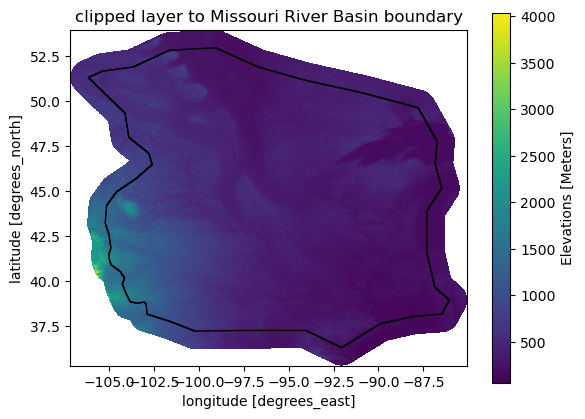

In [26]:
#Plot clipped layer to make sure it looks correct
fig, ax = plt.subplots()
dem_buffered['Data'].plot(ax = ax)
gdf.plot(ax = ax, facecolor = 'None', edgecolor = 'k')
ax.set_title('clipped layer to Missouri River Basin boundary')
ax.set_aspect(1)

In [27]:
krig_uk_dem = UniversalKriging(
    x=measurements["LONGITUDE"],   # x coordinates of gaging stations
    y=measurements["LATITUDE"],    # y coordinates of gaging stations
    z=measurements["D_SWE_OM"],    # SWE values at gaging stations
    drift_terms=['external_Z', 'specified'],  # Including external drift and specified drift terms
    external_drift=dem_2d,         # 2D array of DEM used for external drift
    external_drift_x=lons,         # x coordinates of DEM grid
    external_drift_y=lats,         # y coordinates of DEM grid
    specified_drift=[measurements['DEM_EL']]  # Elevation of gaging stations
)


### Reshape Data and Predict Grid

In [28]:
#Create grid of longitudes and latitudes
lonsi, latsi = np.meshgrid(lons, lats)

# Flatten the arrays
x_pred = np.array(list(zip(lonsi.ravel(), latsi.ravel())))

# Align dimension names with our station data
dem_renamed = dem_buffered.rename({"x": "lon", "y": "lat"})

# Convert the DataArray to Pandas DataFrame
p_pred = dem_renamed.to_dataframe().reset_index()[["lon", "lat", "Data"]]

# Replace NaNs in p_pred["Data"] with zeros for the prediction step
p_pred["Data"].fillna(0, inplace=True)

p_pred

C:\Users\clemasters\AppData\Local\Temp\ipykernel_7636\218795877.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  p_pred["Data"].fillna(0, inplace=True)


,lon,lat,Data
0,-107.145833,53.979167,0.0
1,-107.137500,53.979167,0.0
2,-107.129167,53.979167,0.0
3,-107.120833,53.979167,0.0
4,-107.112500,53.979167,0.0
...,...,...,...
5946188,-85.095833,35.295833,0.0
5946189,-85.087500,35.295833,0.0
5946190,-85.079167,35.295833,0.0
5946191,-85.070833,35.295833,0.0


### Code for smaller regions (UMRB Region)

In [ ]:
# Perform the kriging
z, ss = krig_uk_dem.execute('points', x_pred[:, 0], x_pred[:, 1], specified_drift_arrays=[p_pred["Data"]], backend='loop')

# Reshape the results for plotting
z = z.reshape(lonsi.shape)
ss = ss.reshape(lonsi.shape)

# Plot the kriged values
plt.figure(figsize=(10, 8))
plt.imshow(z, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Interpolated values')
plt.title('Universal Kriging Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Plot the kriging variance
plt.figure(figsize=(10, 8))
plt.imshow(ss, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Kriging Variance')
plt.title('Kriging Variance')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Code for larger assimilation region (chunked code)

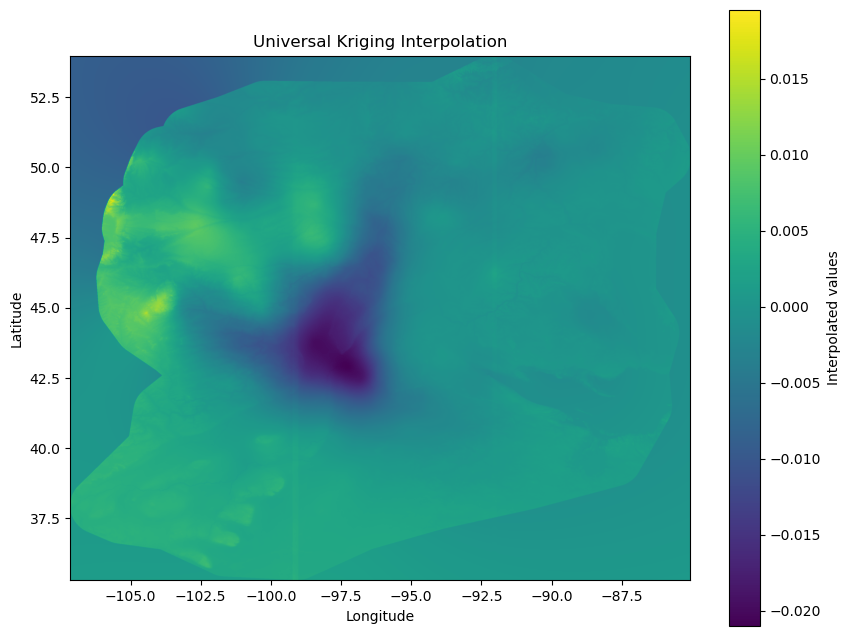

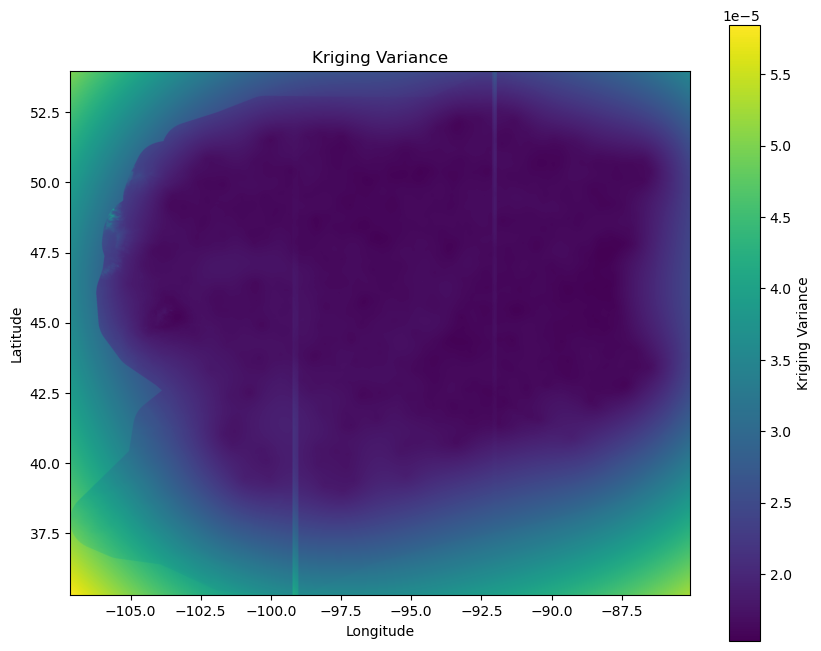

In [29]:
# Function to process chunks
def process_chunk(chunk, p_pred_chunk):
    # Convert p_pred_chunk to a DataFrame to handle NaNs
    p_pred_df = pd.DataFrame(p_pred_chunk, columns=["lon", "lat", "Data"])
    
    # Perform kriging for the current chunk
    z_chunk, ss_chunk = krig_uk_dem.execute(
        'points', 
        chunk[:, 0], 
        chunk[:, 1], 
        specified_drift_arrays=[p_pred_df["Data"].to_numpy()]
    )
    
    # Return the kriged values and variances
    return z_chunk, ss_chunk

# Process data in chunks
chunk_size = 10000
num_chunks = len(x_pred) // chunk_size + 1

predicted_values = []
predicted_variances = []

for i in range(num_chunks):
    # Extract the chunk for x_pred
    chunk = x_pred[i * chunk_size:(i + 1) * chunk_size]
    
    # Extract the corresponding chunk for p_pred
    start_idx = i * chunk_size
    end_idx = min((i + 1) * chunk_size, len(p_pred))
    p_pred_chunk = p_pred.iloc[start_idx:end_idx].to_numpy()
    
    # Predict the values for the current chunk
    predicted_chunk, variance_chunk = process_chunk(chunk, p_pred_chunk)
    predicted_values.append(predicted_chunk)
    predicted_variances.append(variance_chunk)

# Combine results
predicted_values = np.concatenate(predicted_values).reshape(lonsi.shape)
predicted_variances = np.concatenate(predicted_variances).reshape(lonsi.shape)

# Plot the kriged values
plt.figure(figsize=(10, 8))
plt.imshow(predicted_values, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Interpolated values')
plt.title('Universal Kriging Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Plot the kriging variance
plt.figure(figsize=(10, 8))
plt.imshow(predicted_variances, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Kriging Variance')
plt.title('Kriging Variance')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Code below takes the predicted_da from the chunking code for larger datasets and clips to assimilation region

In [31]:
# Convert predicted_values to an xarray DataArray
predicted_da = xr.DataArray(
    predicted_values,
    dims=["y", "x"],
    coords={"y": dem_buffered['y'].values, "x": dem_buffered['x'].values},
    name="predicted_values"
)

# Assign CRS
predicted_da = predicted_da.rio.write_crs("EPSG:4326")

#clip the model grid to the assimilation region
predicted_da = predicted_da.rio.clip(gdf.geometry)

predicted_da

<xarray.DataArray 'predicted_values' (y: 2003, x: 2411)> Size: 39MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y            (y) float64 16kB 52.98 52.97 52.96 52.95 ... 36.31 36.3 36.3
  * x            (x) float64 19kB -106.1 -106.1 -106.1 ... -86.08 -86.07 -86.06
    spatial_ref  int32 4B 0

In [32]:
# Convert predicted_values to an xarray DataArray
predicted_var = xr.DataArray(
    predicted_variances,
    dims=["y", "x"],
    coords={"y": dem_buffered['y'].values, "x": dem_buffered['x'].values},
    name="predicted_values"
)

# Assign CRS
predicted_var = predicted_var.rio.write_crs("EPSG:4326")

#clip the model grid to the assimilation region
predicted_var = predicted_var.rio.clip(gdf.geometry)

predicted_var

<xarray.DataArray 'predicted_values' (y: 2003, x: 2411)> Size: 39MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y            (y) float64 16kB 52.98 52.97 52.96 52.95 ... 36.31 36.3 36.3
  * x            (x) float64 19kB -106.1 -106.1 -106.1 ... -86.08 -86.07 -86.06
    spatial_ref  int32 4B 0

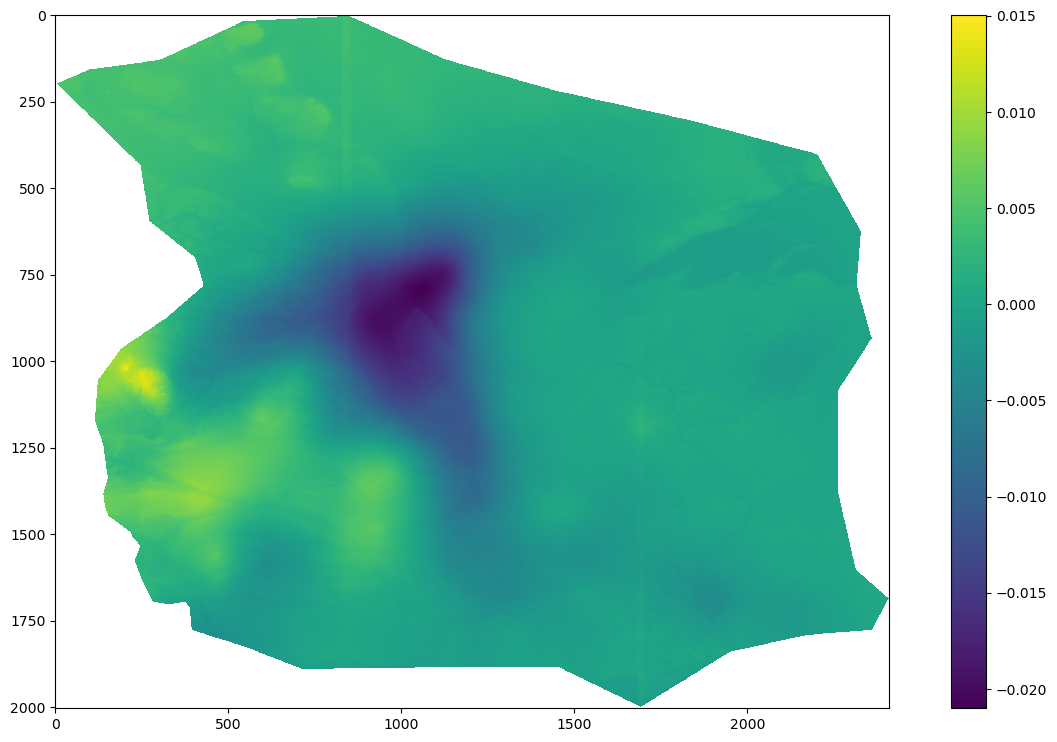

In [33]:
plt.figure(figsize=(16,9))
plt.imshow(predicted_da)
plt.colorbar()
plt.show()

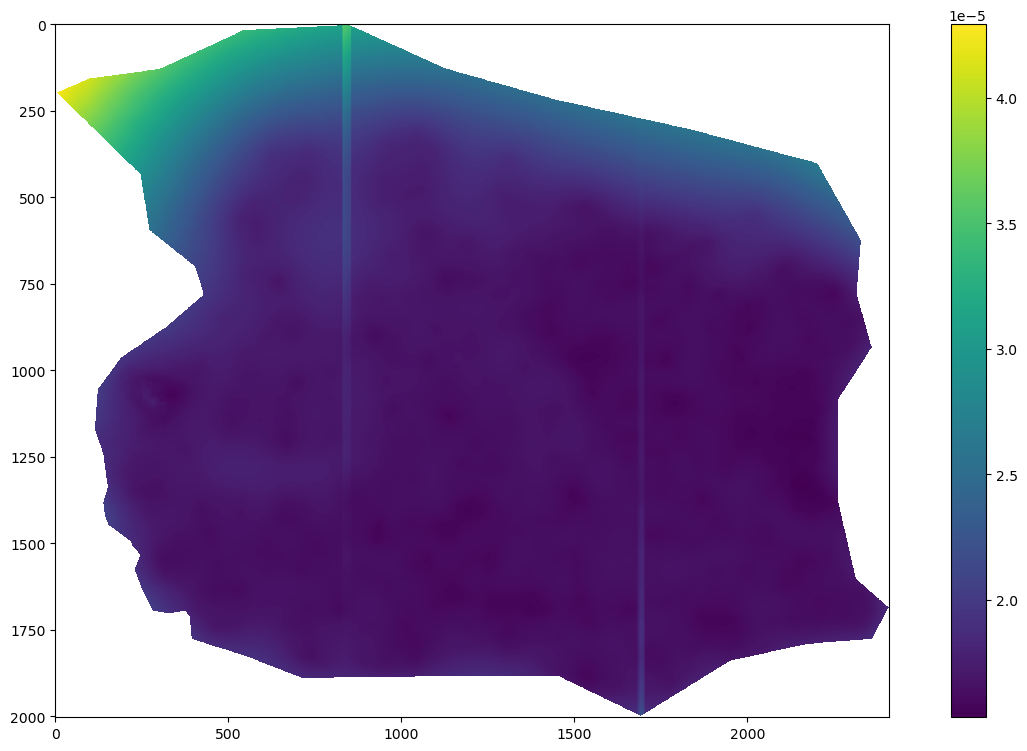

In [34]:
plt.figure(figsize=(16,9))
plt.imshow(predicted_var)
plt.colorbar()
plt.show()

This code saves the universal kriging nudging field layer withing the larger assimilation region

In [35]:
predicted_da.rio.to_raster("universal_kriging_full_assimilation_without_UMRB_12_28_23.tif")

This code saves the universal kriging nudging fields variance withing the larger assimilation region

In [36]:
predicted_var.rio.to_raster("universal_kriging_variance_full_assimilation_without_UMRB_12_28_23.tif")

### Universal Kriging LOO-CV Code

In [ ]:
import numpy as np
import pandas as pd
from pykrige.uk import UniversalKriging
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import matplotlib.pyplot as plt

# Function to perform LOO-CV for Universal Kriging
def loo_cv_kriging(measurements, dem_2d, lons, lats):
    actual_values = []
    predicted_values = []

    # Reset index to ensure we can drop by position
    measurements = measurements.reset_index(drop=True)

    for i in range(len(measurements)):
        # Leave one out
        train = measurements.drop(i)
        test = measurements.iloc[i]

        # Define the Universal Kriging model
        krig_uk_dem = UniversalKriging(
            x=train["LONGITUDE"],   # x coordinates of gaging stations
            y=train["LATITUDE"],    # y coordinates of gaging stations
            z=train["D_SWE_OM"],    # SWE values at gaging stations
            drift_terms=['external_Z', 'specified'],  # Including external drift and specified drift terms
            external_drift=dem_2d,         # 2D array of DEM used for external drift
            external_drift_x=lons,         # x coordinates of DEM grid
            external_drift_y=lats,         # y coordinates of DEM grid
            specified_drift=[train['DEM_EL'].values]  # Elevation of gaging stations
        )

        # Perform kriging for the left-out point
        z_pred, ss_pred = krig_uk_dem.execute(
            'points',
            np.array([test["LONGITUDE"]]),
            np.array([test["LATITUDE"]]),
            specified_drift_arrays=[np.array([test['DEM_EL']])]
        )

        # Store the actual and predicted values
        actual_values.append(test["D_SWE_OM"])
        predicted_values.append(z_pred[0])

    # Compute metrics using all collected actual and predicted values
    rmse = sqrt(mean_squared_error(actual_values, predicted_values))
    mae = mean_absolute_error(actual_values, predicted_values)
    r2 = r2_score(actual_values, predicted_values)
    
    # Plot the results
    plt.figure(figsize=(10, 8))
    plt.scatter(actual_values, predicted_values, color='blue', label='Predicted vs Actual')
    plt.plot([min(actual_values), max(actual_values)], [min(actual_values), max(actual_values)], color='red', label='1:1 Line')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Actual vs Predicted Values with 1:1 Line\nRMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return rmse, mae, r2

# Assuming measurements, dem_2d, lons, lats are defined as in your original context
# Example usage:
rmse, mae, r2 = loo_cv_kriging(measurements, dem_2d, lons, lats)
print(f"LOO-CV RMSE: {rmse}")
print(f"LOO-CV MAE: {mae}")
print(f"LOO-CV R²: {r2}")


## 12/28/23 Assimilation Universal Kriging (Using Elevation as drift) - with UMRB stations

### Load assimilation boundary layer and create polygon geodataframe to clip DEM

In [3]:
# Load assimilation region boundary
boundary = xr.open_dataset(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\ssm_process_region_2023122712_2023122812_swe_central.nc')

# Select the variable of interest
variable_name = 'Data'  # Replace with the actual variable name
data = boundary[variable_name]

# Create a boolean mask (e.g., mask for values greater than a threshold)
mask = data == 100

# Convert the mask to a numpy array
mask_array = mask.values

# Assuming the variable has 'lat' and 'lon' as dimensions
latitudes = data['lat'].values
longitudes = data['lon'].values

# Transform the mask array into polygons
polygons = []
transform = rasterio.transform.from_bounds(
    west=min(longitudes), 
    south=min(latitudes),
    east=max(longitudes), 
    north=max(latitudes), 
    width=mask_array.shape[1],
    height=mask_array.shape[0]
)

# Extract shapes where the mask is True (data == 100)
for geom, val in shapes(mask_array.astype(np.int32), mask=mask_array, transform=transform):
    if val == 1:  # If the condition is met (data == 100)
        polygons.append(shape(geom))


# Create a GeoDataFrame from the polygons
gdf = gpd.GeoDataFrame({'geometry': polygons}, crs='EPSG:4326')

# Print the GeoDataFrame to check the results
print(gdf)

                                            geometry
0  POLYGON ((-99.21651 52.98003, -99.21651 52.971...


### Upload DEM and add elevation data to stations

In [4]:
# add DEM elevation to all stations that didn't have elevation data
#Path to your NetCDF file
file_path = r"C:\Repos\umrb-snodas\resources\Terrain_GMTED_2010_30sec.ea.nc"

# Open the dataset
dem = xr.open_dataset(file_path)

# Select a subset of the data
#precip_2022 = precip_2022.sel(day=slice('2022-10-01', '2022-12-31'))

# Compute the subset
dem = dem.compute()

dem

<xarray.Dataset> Size: 802MB
Dimensions:     (lat: 6960, lon: 14400, nv: 2)
Coordinates:
  * lat         (lat) float64 56kB 72.0 71.99 71.98 71.97 ... 14.02 14.01 14.0
  * lon         (lon) float64 115kB -170.0 -170.0 -170.0 ... -50.02 -50.01 -50.0
Dimensions without coordinates: nv
Data variables:
    lat_bounds  (lat, nv) float64 111kB 72.0 71.99 71.99 ... 14.01 14.01 14.0
    lon_bounds  (lon, nv) float64 230kB -170.0 -170.0 -170.0 ... -50.01 -50.0
    Data        (lat, lon) float64 802MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    crs         int32 4B -2147483647
Attributes:
    comment:         2013-08-29 09:46:55 UTC created comment: Not applicable\...
    history:         2013-08-29 09:46:55 UTC created by module: DEM_in_any\n2...
    format_version:  NOHRSC NetCDF raster file v1.2
    Conventions:     CF-1.6
    references:      Not applicable
    source:          Not applicable
    title:           Not applicable

In [5]:
# Load shapefile that contains stations and delta SWE from the 12/28/23 assimilation
shapefile_path = r"C:\Repos\umrb-snodas\Test_Runs\snodas_assim_20231228_with_umrb_updated_base\ssm1054_md_based_2023122712_2023122812_central.shp"

# Load shapefile
measurements = gpd.read_file(shapefile_path)

# Drop all points that arent stations
measurements  = measurements [measurements ['VALUE'] != 1]

# Just keep the columns Latitude, Longitude, Station_id, station_ty, station_elevation, DEM_elevation, Forest_den, D_SWE_OM
# Keep only the specified columns
columns_to_keep = ['VALUE', 'LATITUDE', 'LONGITUDE', 'STATION_ID', 'STATION_TY', 'STATION_EL', 'DEM_ELEVAT', 'FOREST_DEN', 'MD_DEPTH_T','D_SWE_OM', 'OB_SWE', 'MD_SWE']

measurements  = measurements [columns_to_keep]

measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE
1707,NaN,43.1653,-95.1467,3SE,COOPABC,403.0,405.0,3.0,2023-12-28 06,0.000000,0.000000,0.000000
1708,NaN,45.6708,-96.9961,8D3,ASOS,353.0,350.0,5.0,2023-12-28 12,-0.020945,0.013836,0.034780
1709,NaN,45.4553,-98.4141,ABES2,COOPABC,395.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652
1710,NaN,45.4825,-87.8119,ABGW3,UCOOP,224.0,223.0,53.0,2023-12-28 12,0.000000,0.000000,0.000000
1711,NaN,45.4558,-98.4128,ABR,"ASOS, AWIPS, COOPABC, CRS, UA, WSR88D",396.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652
...,...,...,...,...,...,...,...,...,...,...,...,...
3295,NaN,47.2719,-100.3303,WNGN8,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,0.003200,0.003200,0.000000
3296,NaN,43.3100,-99.6900,WNMS2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,-0.002164,0.020997,0.023161
3297,NaN,43.5600,-100.7400,WRIS2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,0.010744,0.041354,0.030611
3298,NaN,43.7322,-98.6939,WTES2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,-0.008791,0.020626,0.029417


In [6]:
# Initialize an empty list to store surface radiation
DEM_EL = []

# Extracting data based on lat, lon, and time from Dec_28_2023_stations
for index, (lat, lon) in measurements[['LATITUDE', 'LONGITUDE']].iterrows():

    DEM_values = dem.sel(lat=lat, lon=lon, method='nearest')['Data'].item()
    
    # Append wind speed to the list
    DEM_EL.append(DEM_values)

# Add 'wind_speed' column to Dec_28_2023_stations
measurements['DEM_EL'] = DEM_EL

# Display the updated DataFrame
measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE,DEM_EL
1707,NaN,43.1653,-95.1467,3SE,COOPABC,403.0,405.0,3.0,2023-12-28 06,0.000000,0.000000,0.000000,405.0
1708,NaN,45.6708,-96.9961,8D3,ASOS,353.0,350.0,5.0,2023-12-28 12,-0.020945,0.013836,0.034780,350.0
1709,NaN,45.4553,-98.4141,ABES2,COOPABC,395.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652,395.0
1710,NaN,45.4825,-87.8119,ABGW3,UCOOP,224.0,223.0,53.0,2023-12-28 12,0.000000,0.000000,0.000000,223.0
1711,NaN,45.4558,-98.4128,ABR,"ASOS, AWIPS, COOPABC, CRS, UA, WSR88D",396.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652,395.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295,NaN,47.2719,-100.3303,WNGN8,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,0.003200,0.003200,0.000000,596.0
3296,NaN,43.3100,-99.6900,WNMS2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,-0.002164,0.020997,0.023161,637.0
3297,NaN,43.5600,-100.7400,WRIS2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,0.010744,0.041354,0.030611,654.0
3298,NaN,43.7322,-98.6939,WTES2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,-0.008791,0.020626,0.029417,498.0


### Load DEM and Clip and add Buffer

In [7]:
# Load high-resolution DEM with xarray.open_rasterio
dem = xr.open_dataset(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\Terrain_GMTED_2010_30sec.ea.nc')

dem = dem.rio.write_crs('WGS84')

# If dimensions are not 'x' and 'y', set them explicitly
dem = dem.rio.set_spatial_dims("lon", "lat", inplace=True)

dem = dem.rename({'lon': 'x', 'lat': 'y'})

# Drop 'lat_bounds' and 'lon_bounds' variables
dem = dem.drop_vars(['lat_bounds', 'lon_bounds'])

dem_region_clipped = dem.rio.clip(gdf.geometry, gdf.crs)

# Create a buffer around the geometry
buffer_distance = 1.0  # Adjust this distance as needed (in degrees, meters, etc. depending on your CRS)
gdf_buffered = gdf.copy()
gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(buffer_distance)

# Clip the DEM with the buffered geometry
dem_buffered = dem.rio.clip(gdf_buffered.geometry, gdf_buffered.crs)


#Extract and convert coordinates to lists
lons = dem_buffered['x'].values
lats = dem_buffered['y'].values

# Convert the clipped DEM data array to a 2D array
dem_2d = dem_buffered.to_array().isel(variable=0).values

# Replace all NaN values with zero
dem_2d = np.nan_to_num(dem_2d, nan=0.0)

C:\Users\clemasters\AppData\Local\Temp\ipykernel_4324\2895085862.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(buffer_distance)


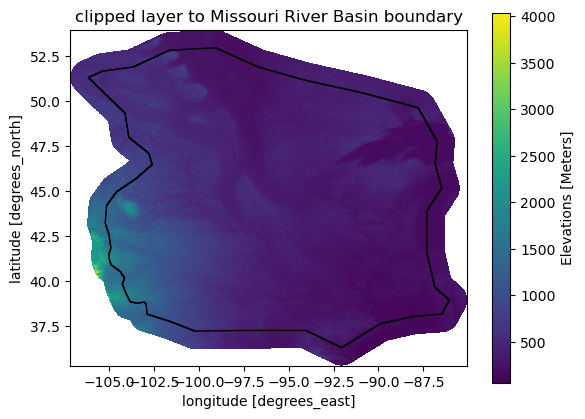

In [8]:
#Plot clipped layer to make sure it looks correct
fig, ax = plt.subplots()
dem_buffered['Data'].plot(ax = ax)
gdf.plot(ax = ax, facecolor = 'None', edgecolor = 'k')
ax.set_title('clipped layer to Missouri River Basin boundary')
ax.set_aspect(1)

In [108]:
krig_uk_dem = UniversalKriging(
    x=measurements["LONGITUDE"],   # x coordinates of gaging stations
    y=measurements["LATITUDE"],    # y coordinates of gaging stations
    z=measurements["D_SWE_OM"],    # SWE values at gaging stations
    drift_terms=['external_Z', 'specified'],  # Including external drift and specified drift terms
    external_drift=dem_2d,         # 2D array of DEM used for external drift
    external_drift_x=lons,         # x coordinates of DEM grid
    external_drift_y=lats,         # y coordinates of DEM grid
    specified_drift=[measurements['DEM_EL']]  # Elevation of gaging stations
)

### Reshape Data and Predict Grid

In [109]:
#Create grid of longitudes and latitudes
lonsi, latsi = np.meshgrid(lons, lats)

# Flatten the arrays
x_pred = np.array(list(zip(lonsi.ravel(), latsi.ravel())))

# Align dimension names with our station data
dem_renamed = dem_buffered.rename({"x": "lon", "y": "lat"})

# Convert the DataArray to Pandas DataFrame
p_pred = dem_renamed.to_dataframe().reset_index()[["lon", "lat", "Data"]]

# Replace NaNs in p_pred["Data"] with zeros for the prediction step
p_pred["Data"].fillna(0, inplace=True)

p_pred

C:\Users\clemasters\AppData\Local\Temp\ipykernel_7636\218795877.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  p_pred["Data"].fillna(0, inplace=True)


,lon,lat,Data
0,-107.145833,53.979167,0.0
1,-107.137500,53.979167,0.0
2,-107.129167,53.979167,0.0
3,-107.120833,53.979167,0.0
4,-107.112500,53.979167,0.0
...,...,...,...
5946188,-85.095833,35.295833,0.0
5946189,-85.087500,35.295833,0.0
5946190,-85.079167,35.295833,0.0
5946191,-85.070833,35.295833,0.0


### Code for smaller regions (UMRB Region)

In [ ]:
# Perform the kriging
z, ss = krig_uk_dem.execute('points', x_pred[:, 0], x_pred[:, 1], specified_drift_arrays=[p_pred["Data"]], backend='loop')

# Reshape the results for plotting
z = z.reshape(lonsi.shape)
ss = ss.reshape(lonsi.shape)

# Plot the kriged values
plt.figure(figsize=(10, 8))
plt.imshow(z, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Interpolated values')
plt.title('Universal Kriging Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Plot the kriging variance
plt.figure(figsize=(10, 8))
plt.imshow(ss, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Kriging Variance')
plt.title('Kriging Variance')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Code for larger assimilation region (chunked code)

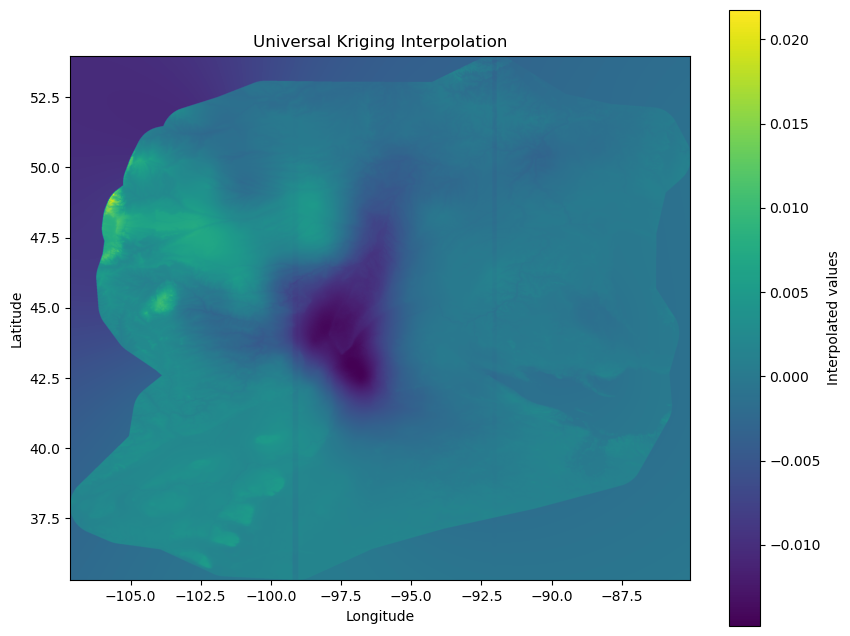

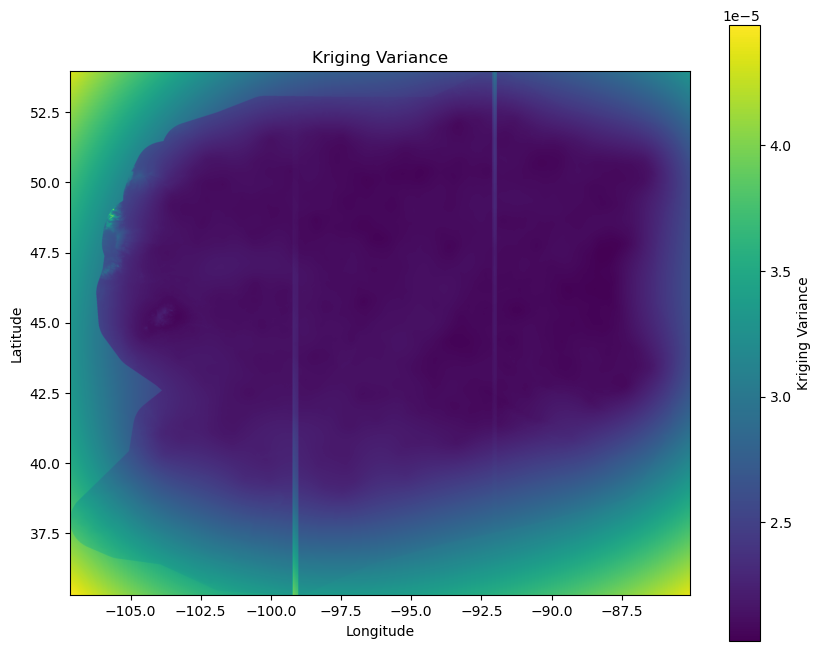

In [45]:
# Function to process chunks
def process_chunk(chunk, p_pred_chunk):
    # Convert p_pred_chunk to a DataFrame to handle NaNs
    p_pred_df = pd.DataFrame(p_pred_chunk, columns=["lon", "lat", "Data"])
    
    # Perform kriging for the current chunk
    z_chunk, ss_chunk = krig_uk_dem.execute(
        'points', 
        chunk[:, 0], 
        chunk[:, 1], 
        specified_drift_arrays=[p_pred_df["Data"].to_numpy()]
    )
    
    # Return the kriged values and variances
    return z_chunk, ss_chunk

# Process data in chunks
chunk_size = 10000
num_chunks = len(x_pred) // chunk_size + 1

predicted_values = []
predicted_variances = []

for i in range(num_chunks):
    # Extract the chunk for x_pred
    chunk = x_pred[i * chunk_size:(i + 1) * chunk_size]
    
    # Extract the corresponding chunk for p_pred
    start_idx = i * chunk_size
    end_idx = min((i + 1) * chunk_size, len(p_pred))
    p_pred_chunk = p_pred.iloc[start_idx:end_idx].to_numpy()
    
    # Predict the values for the current chunk
    predicted_chunk, variance_chunk = process_chunk(chunk, p_pred_chunk)
    predicted_values.append(predicted_chunk)
    predicted_variances.append(variance_chunk)

# Combine results
predicted_values = np.concatenate(predicted_values).reshape(lonsi.shape)
predicted_variances = np.concatenate(predicted_variances).reshape(lonsi.shape)

# Plot the kriged values
plt.figure(figsize=(10, 8))
plt.imshow(predicted_values, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Interpolated values')
plt.title('Universal Kriging Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Plot the kriging variance
plt.figure(figsize=(10, 8))
plt.imshow(predicted_variances, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Kriging Variance')
plt.title('Kriging Variance')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Code below takes the predicted_da from the chunking code for larger datasets and clips to assimilation region

In [46]:
# Convert predicted_values to an xarray DataArray
predicted_da = xr.DataArray(
    predicted_values,
    dims=["y", "x"],
    coords={"y": dem_buffered['y'].values, "x": dem_buffered['x'].values},
    name="predicted_values"
)

# Assign CRS
predicted_da = predicted_da.rio.write_crs("EPSG:4326")

#clip the model grid to the assimilation region
predicted_da = predicted_da.rio.clip(gdf.geometry)

predicted_da

<xarray.DataArray 'predicted_values' (y: 2003, x: 2411)> Size: 39MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y            (y) float64 16kB 52.98 52.97 52.96 52.95 ... 36.31 36.3 36.3
  * x            (x) float64 19kB -106.1 -106.1 -106.1 ... -86.08 -86.07 -86.06
    spatial_ref  int32 4B 0

In [47]:
# Convert predicted_values to an xarray DataArray
predicted_var = xr.DataArray(
    predicted_variances,
    dims=["y", "x"],
    coords={"y": dem_buffered['y'].values, "x": dem_buffered['x'].values},
    name="predicted_values"
)

# Assign CRS
predicted_var = predicted_var.rio.write_crs("EPSG:4326")

#clip the model grid to the assimilation region
predicted_var = predicted_var.rio.clip(gdf.geometry)

predicted_var

<xarray.DataArray 'predicted_values' (y: 2003, x: 2411)> Size: 39MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y            (y) float64 16kB 52.98 52.97 52.96 52.95 ... 36.31 36.3 36.3
  * x            (x) float64 19kB -106.1 -106.1 -106.1 ... -86.08 -86.07 -86.06
    spatial_ref  int32 4B 0

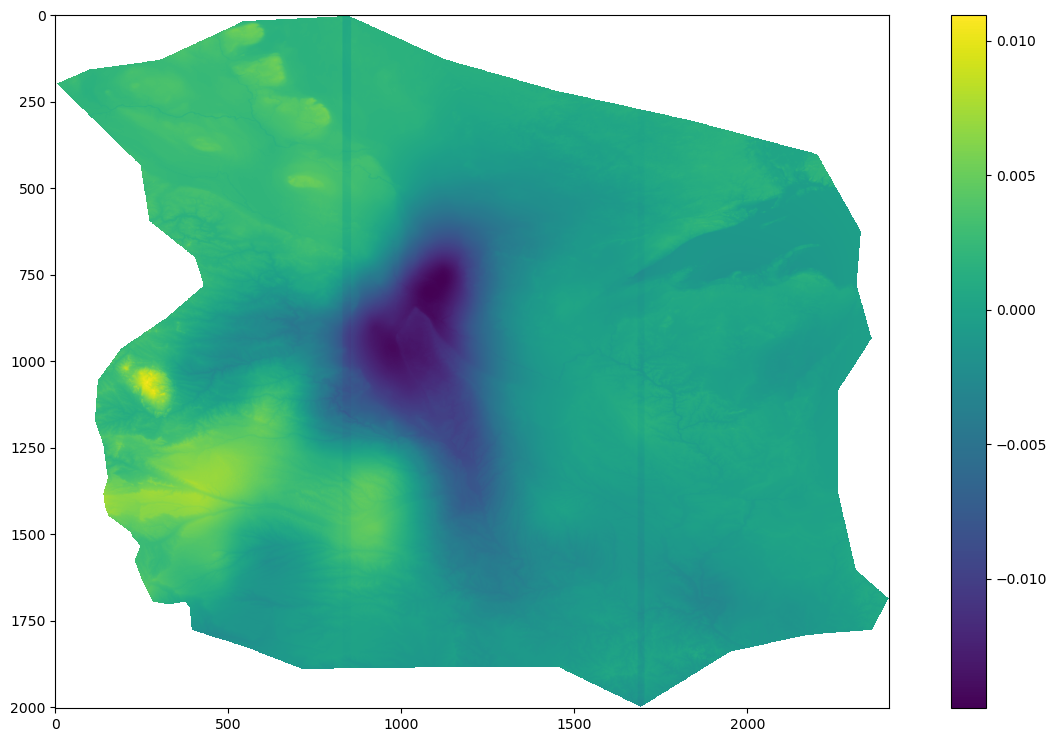

In [48]:
plt.figure(figsize=(16,9))
plt.imshow(predicted_da)
plt.colorbar()
plt.show()

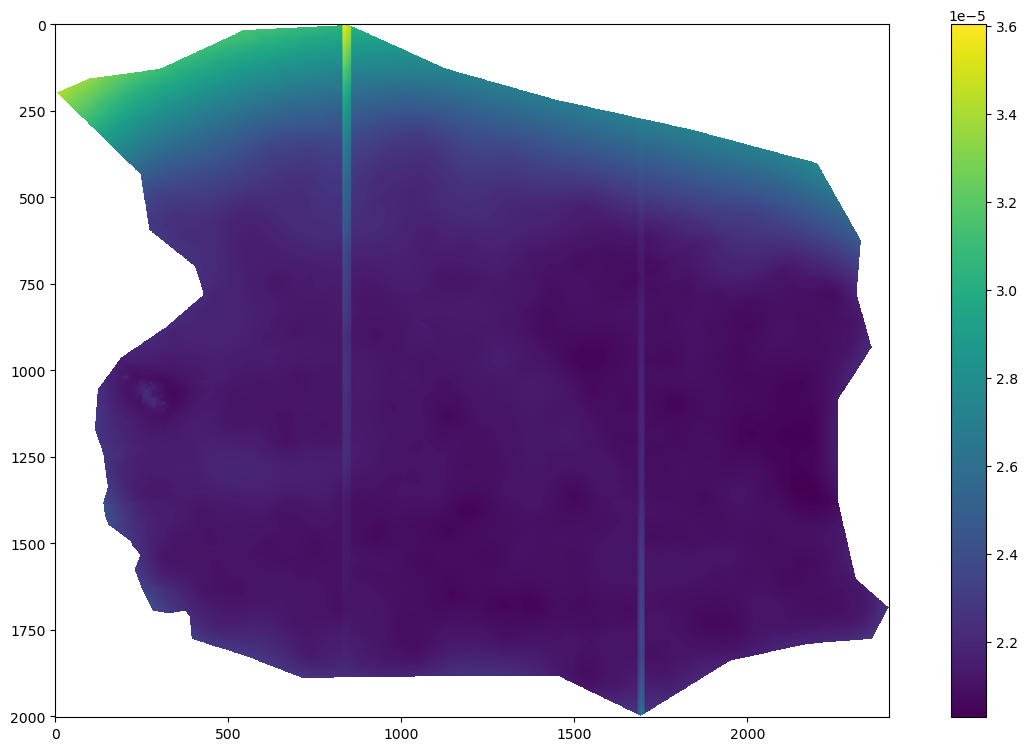

In [49]:
plt.figure(figsize=(16,9))
plt.imshow(predicted_var)
plt.colorbar()
plt.show()

This code saves the universal kriging nudging field layer withing the larger assimilation region

In [50]:
predicted_da.rio.to_raster("universal_kriging_full_assimilation_with_UMRB_12_28_23.tif")

This code saves the universal kriging nudging fields variance withing the larger assimilation region

In [51]:
predicted_var.rio.to_raster("universal_kriging_variance_full_assimilation_with_UMRB_12_28_23.tif")

### Universal Kriging LOO-CV Code

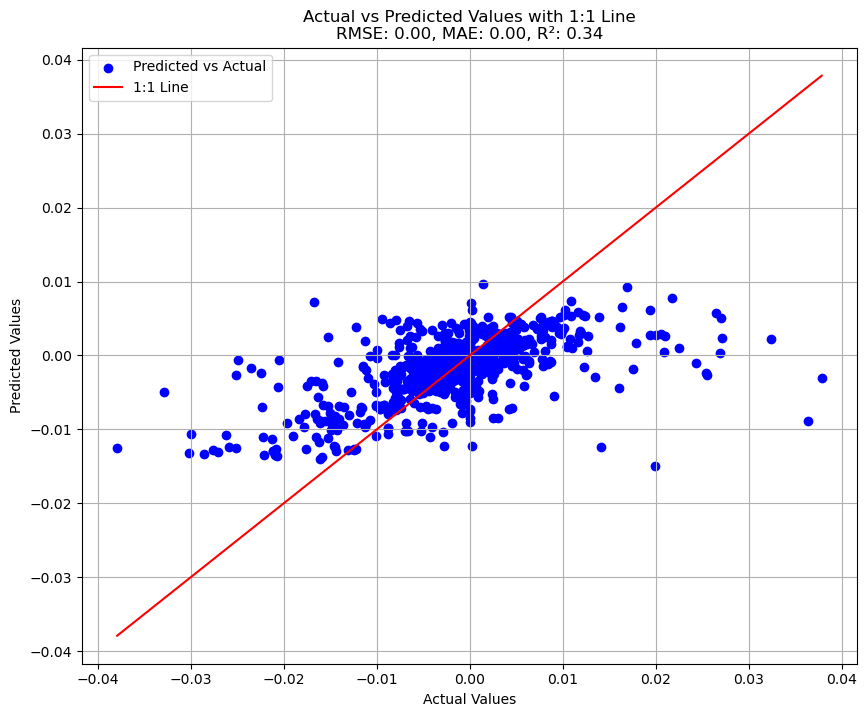

LOO-CV RMSE: 0.004892509366907636
LOO-CV MAE: 0.0024541464799933783
LOO-CV R²: 0.3378798657412403


In [110]:
import numpy as np
import pandas as pd
from pykrige.uk import UniversalKriging
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import matplotlib.pyplot as plt

# Function to perform LOO-CV for Universal Kriging
def loo_cv_kriging(measurements, dem_2d, lons, lats):
    actual_values = []
    predicted_values = []

    # Reset index to ensure we can drop by position
    measurements = measurements.reset_index(drop=True)

    for i in range(len(measurements)):
        # Leave one out
        train = measurements.drop(i)
        test = measurements.iloc[i]

        # Define the Universal Kriging model
        krig_uk_dem = UniversalKriging(
            x=train["LONGITUDE"],   # x coordinates of gaging stations
            y=train["LATITUDE"],    # y coordinates of gaging stations
            z=train["D_SWE_OM"],    # SWE values at gaging stations
            drift_terms=['external_Z', 'specified'],  # Including external drift and specified drift terms
            external_drift=dem_2d,         # 2D array of DEM used for external drift
            external_drift_x=lons,         # x coordinates of DEM grid
            external_drift_y=lats,         # y coordinates of DEM grid
            specified_drift=[train['DEM_EL'].values]  # Elevation of gaging stations
        )

        # Perform kriging for the left-out point
        z_pred, ss_pred = krig_uk_dem.execute(
            'points',
            np.array([test["LONGITUDE"]]),
            np.array([test["LATITUDE"]]),
            specified_drift_arrays=[np.array([test['DEM_EL']])]
        )

        # Store the actual and predicted values
        actual_values.append(test["D_SWE_OM"])
        predicted_values.append(z_pred[0])

    # Compute metrics using all collected actual and predicted values
    rmse = sqrt(mean_squared_error(actual_values, predicted_values))
    mae = mean_absolute_error(actual_values, predicted_values)
    r2 = r2_score(actual_values, predicted_values)
    
    # Plot the results
    plt.figure(figsize=(10, 8))
    plt.scatter(actual_values, predicted_values, color='blue', label='Predicted vs Actual')
    plt.plot([min(actual_values), max(actual_values)], [min(actual_values), max(actual_values)], color='red', label='1:1 Line')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Actual vs Predicted Values with 1:1 Line\nRMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return rmse, mae, r2

# Assuming measurements, dem_2d, lons, lats are defined as in your original context
# Example usage:
rmse, mae, r2 = loo_cv_kriging(measurements, dem_2d, lons, lats)
print(f"LOO-CV RMSE: {rmse}")
print(f"LOO-CV MAE: {mae}")
print(f"LOO-CV R²: {r2}")


## 01/10/24 Assimilation Universal Kriging (Using Elevation as drift) - without UMRB stations

### Load assimilation boundary layer and create polygon geodataframe to clip DEM

In [85]:
# Load assimilation region boundary
boundary = xr.open_dataset(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_20240110_with_umrb\ssm_process_region_2024010912_2024011012_swe_central.nc')

# Select the variable of interest
variable_name = 'Data'  # Replace with the actual variable name
data = boundary[variable_name]

# Create a boolean mask (e.g., mask for values greater than a threshold)
mask = data == 100

# Convert the mask to a numpy array
mask_array = mask.values

# Assuming the variable has 'lat' and 'lon' as dimensions
latitudes = data['lat'].values
longitudes = data['lon'].values

# Transform the mask array into polygons
polygons = []
transform = rasterio.transform.from_bounds(
    west=min(longitudes), 
    south=min(latitudes),
    east=max(longitudes), 
    north=max(latitudes), 
    width=mask_array.shape[1],
    height=mask_array.shape[0]
)

# Extract shapes where the mask is True (data == 100)
for geom, val in shapes(mask_array.astype(np.int32), mask=mask_array, transform=transform):
    if val == 1:  # If the condition is met (data == 100)
        polygons.append(shape(geom))


# Create a GeoDataFrame from the polygons
gdf = gpd.GeoDataFrame({'geometry': polygons}, crs='EPSG:4326')

# Print the GeoDataFrame to check the results
print(gdf)

                                            geometry
0  POLYGON ((-69.31162 48.30617, -69.31162 48.297...
1  POLYGON ((-97.39172 50.90554, -97.39172 50.897...


### Upload DEM and add elevation data to stations

In [86]:
# add DEM elevation to all stations that didn't have elevation data
#Path to your NetCDF file
file_path = r"C:\Repos\umrb-snodas\resources\Terrain_GMTED_2010_30sec.ea.nc"

# Open the dataset
dem = xr.open_dataset(file_path)

# Select a subset of the data
#precip_2022 = precip_2022.sel(day=slice('2022-10-01', '2022-12-31'))

# Compute the subset
dem = dem.compute()

dem

<xarray.Dataset> Size: 802MB
Dimensions:     (lat: 6960, lon: 14400, nv: 2)
Coordinates:
  * lat         (lat) float64 56kB 72.0 71.99 71.98 71.97 ... 14.02 14.01 14.0
  * lon         (lon) float64 115kB -170.0 -170.0 -170.0 ... -50.02 -50.01 -50.0
Dimensions without coordinates: nv
Data variables:
    lat_bounds  (lat, nv) float64 111kB 72.0 71.99 71.99 ... 14.01 14.01 14.0
    lon_bounds  (lon, nv) float64 230kB -170.0 -170.0 -170.0 ... -50.01 -50.0
    Data        (lat, lon) float64 802MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    crs         int32 4B -2147483647
Attributes:
    comment:         2013-08-29 09:46:55 UTC created comment: Not applicable\...
    history:         2013-08-29 09:46:55 UTC created by module: DEM_in_any\n2...
    format_version:  NOHRSC NetCDF raster file v1.2
    Conventions:     CF-1.6
    references:      Not applicable
    source:          Not applicable
    title:           Not applicable

In [87]:
# Load shapefile that contains stations and delta SWE from the 01/10/24 assimilation
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_20240110_with_umrb\ssm1054_md_based_2024010912_2024011012_central.shp"

# Load shapefile
measurements = gpd.read_file(shapefile_path)

# Drop all points that arent stations
measurements  = measurements [measurements ['VALUE'] != 1]

# Just keep the columns Latitude, Longitude, Station_id, station_ty, station_elevation, DEM_elevation, Forest_den, D_SWE_OM
# Keep only the specified columns
columns_to_keep = ['VALUE', 'LATITUDE', 'LONGITUDE', 'STATION_ID', 'STATION_TY', 'STATION_EL', 'DEM_ELEVAT', 'FOREST_DEN', 'MD_DEPTH_T','D_SWE_OM', 'OB_SWE', 'MD_SWE']

measurements  = measurements [columns_to_keep]

measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE
3401,NaN,43.1653,-95.1467,3SE,COOPABC,403.0,405.0,3.0,2024-01-10 06,0.009460,0.014676,0.005216
3402,NaN,41.4461,-83.3289,41.4461_083.3289,SPOTTER,190.0,191.0,4.0,2024-01-09 13,-0.009658,0.000006,0.009664
3403,NaN,41.6383,-83.5281,41.6383_083.5281,SPOTTER,187.0,182.0,6.0,2024-01-09 13,-0.005330,0.001103,0.006434
3404,NaN,45.6708,-96.9961,8D3,ASOS,353.0,350.0,5.0,2024-01-10 12,-0.002804,0.010363,0.013167
3405,NaN,42.2416,-83.6933,AASM4,COOPAB,254.0,255.0,23.0,2024-01-10 12,-0.000560,0.000004,0.000564
...,...,...,...,...,...,...,...,...,...,...,...,...
7053,NaN,47.2719,-100.3303,WNGN8,UMRB,-9999.0,-9999.0,-9999.0,2024/01/10 12:,-0.005429,0.001523,0.006952
7054,NaN,43.3100,-99.6900,WNMS2,UMRB,-9999.0,-9999.0,-9999.0,2024/01/10 12:,0.004828,0.031294,0.026466
7055,NaN,43.5600,-100.7400,WRIS2,UMRB,-9999.0,-9999.0,-9999.0,2024/01/10 12:,0.011779,0.052519,0.040740
7056,NaN,43.7322,-98.6939,WTES2,UMRB,-9999.0,-9999.0,-9999.0,2024/01/10 12:,0.000953,0.023290,0.022337


In [88]:
# Initialize an empty list to store surface radiation
DEM_EL = []

# Extracting data based on lat, lon, and time from Dec_28_2023_stations
for index, (lat, lon) in measurements[['LATITUDE', 'LONGITUDE']].iterrows():

    DEM_values = dem.sel(lat=lat, lon=lon, method='nearest')['Data'].item()
    
    # Append wind speed to the list
    DEM_EL.append(DEM_values)

# Add 'wind_speed' column to Dec_28_2023_stations
measurements['DEM_EL'] = DEM_EL

# Display the updated DataFrame
measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE,DEM_EL
3401,NaN,43.1653,-95.1467,3SE,COOPABC,403.0,405.0,3.0,2024-01-10 06,0.009460,0.014676,0.005216,405.0
3402,NaN,41.4461,-83.3289,41.4461_083.3289,SPOTTER,190.0,191.0,4.0,2024-01-09 13,-0.009658,0.000006,0.009664,191.0
3403,NaN,41.6383,-83.5281,41.6383_083.5281,SPOTTER,187.0,182.0,6.0,2024-01-09 13,-0.005330,0.001103,0.006434,182.0
3404,NaN,45.6708,-96.9961,8D3,ASOS,353.0,350.0,5.0,2024-01-10 12,-0.002804,0.010363,0.013167,350.0
3405,NaN,42.2416,-83.6933,AASM4,COOPAB,254.0,255.0,23.0,2024-01-10 12,-0.000560,0.000004,0.000564,255.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7053,NaN,47.2719,-100.3303,WNGN8,UMRB,-9999.0,-9999.0,-9999.0,2024/01/10 12:,-0.005429,0.001523,0.006952,596.0
7054,NaN,43.3100,-99.6900,WNMS2,UMRB,-9999.0,-9999.0,-9999.0,2024/01/10 12:,0.004828,0.031294,0.026466,637.0
7055,NaN,43.5600,-100.7400,WRIS2,UMRB,-9999.0,-9999.0,-9999.0,2024/01/10 12:,0.011779,0.052519,0.040740,654.0
7056,NaN,43.7322,-98.6939,WTES2,UMRB,-9999.0,-9999.0,-9999.0,2024/01/10 12:,0.000953,0.023290,0.022337,498.0


### Create a list of all the UMRB station_id's and filter them out of dataframe

In [89]:
# Create a list of all UMRB Station names so you can remove from assimilation

# Read the CSV file
UMRB_ID = pd.read_csv(r'C:\Repos\umrb-snodas\resources\Current_UMRB_Station_List.csv')

# Create station ID List
UMRB_ID = UMRB_ID['station_id'].to_list()

# Filter the DataFrame
measurements = measurements[~measurements['STATION_ID'].isin(UMRB_ID)]

measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE,DEM_EL
3401,NaN,43.1653,-95.1467,3SE,COOPABC,403.0,405.0,3.0,2024-01-10 06,0.009460,0.014676,0.005216,405.0
3402,NaN,41.4461,-83.3289,41.4461_083.3289,SPOTTER,190.0,191.0,4.0,2024-01-09 13,-0.009658,0.000006,0.009664,191.0
3403,NaN,41.6383,-83.5281,41.6383_083.5281,SPOTTER,187.0,182.0,6.0,2024-01-09 13,-0.005330,0.001103,0.006434,182.0
3404,NaN,45.6708,-96.9961,8D3,ASOS,353.0,350.0,5.0,2024-01-10 12,-0.002804,0.010363,0.013167,350.0
3405,NaN,42.2416,-83.6933,AASM4,COOPAB,254.0,255.0,23.0,2024-01-10 12,-0.000560,0.000004,0.000564,255.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6976,NaN,44.5272,-69.6544,WVLM1,COOPAB,17.0,21.0,49.0,2024-01-09 15,0.004361,0.017238,0.012877,21.0
6977,NaN,39.8986,-80.1656,WYNP1,COOPAB,288.0,299.0,20.0,2024-01-10 12,0.000000,0.000000,0.000000,299.0
6978,NaN,42.8202,-78.1478,WYON6,COOPAB,481.0,472.0,61.0,2024-01-10 12,0.000003,0.000003,0.000000,472.0
6979,NaN,42.7344,-71.4803,ZBWN3,COOPBC,51.0,53.0,17.0,2024-01-10 12,-0.027487,0.015237,0.042725,53.0


### Load DEM and Station Data

In [90]:
# Load high-resolution DEM with xarray.open_rasterio
dem = xr.open_dataset(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\Terrain_GMTED_2010_30sec.ea.nc')

dem = dem.rio.write_crs('WGS84')

# If dimensions are not 'x' and 'y', set them explicitly
dem = dem.rio.set_spatial_dims("lon", "lat", inplace=True)

dem = dem.rename({'lon': 'x', 'lat': 'y'})

# Drop 'lat_bounds' and 'lon_bounds' variables
dem = dem.drop_vars(['lat_bounds', 'lon_bounds'])

dem_region_clipped = dem.rio.clip(gdf.geometry, gdf.crs)

# Create a buffer around the geometry
buffer_distance = 1.0  # Adjust this distance as needed (in degrees, meters, etc. depending on your CRS)
gdf_buffered = gdf.copy()
gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(buffer_distance)

# Clip the DEM with the buffered geometry
dem_buffered = dem.rio.clip(gdf_buffered.geometry, gdf_buffered.crs)


#Extract and convert coordinates to lists
lons = dem_buffered['x'].values
lats = dem_buffered['y'].values

# Convert the clipped DEM data array to a 2D array
dem_2d = dem_buffered.to_array().isel(variable=0).values

# Replace all NaN values with zero
dem_2d = np.nan_to_num(dem_2d, nan=0.0)

C:\Users\clemasters\AppData\Local\Temp\ipykernel_7636\2895085862.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(buffer_distance)


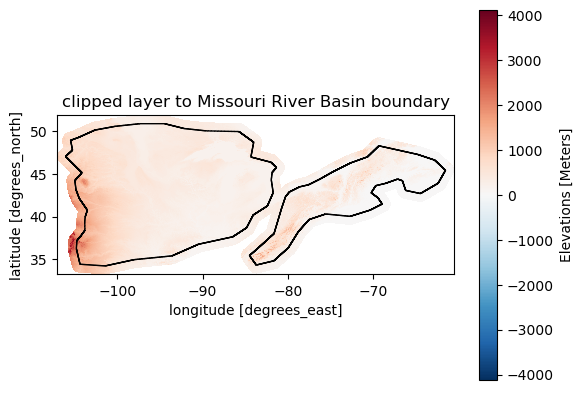

In [91]:
#Plot clipped layer to make sure it looks correct
fig, ax = plt.subplots()
dem_buffered['Data'].plot(ax = ax)
gdf.plot(ax = ax, facecolor = 'None', edgecolor = 'k')
ax.set_title('clipped layer to Missouri River Basin boundary')
ax.set_aspect(1)

In [92]:
krig_uk_dem = UniversalKriging(
    x=measurements["LONGITUDE"],   # x coordinates of gaging stations
    y=measurements["LATITUDE"],    # y coordinates of gaging stations
    z=measurements["D_SWE_OM"],    # SWE values at gaging stations
    drift_terms=['external_Z', 'specified'],  # Including external drift and specified drift terms
    external_drift=dem_2d,         # 2D array of DEM used for external drift
    external_drift_x=lons,         # x coordinates of DEM grid
    external_drift_y=lats,         # y coordinates of DEM grid
    specified_drift=[measurements['DEM_EL']]  # Elevation of gaging stations
)


### Reshape Data and Predict Grid

In [93]:
#Create grid of longitudes and latitudes
lonsi, latsi = np.meshgrid(lons, lats)

# Flatten the arrays
x_pred = np.array(list(zip(lonsi.ravel(), latsi.ravel())))

# Align dimension names with our station data
dem_renamed = dem_buffered.rename({"x": "lon", "y": "lat"})

# Convert the DataArray to Pandas DataFrame
p_pred = dem_renamed.to_dataframe().reset_index()[["lon", "lat", "Data"]]

# Replace NaNs in p_pred["Data"] with zeros for the prediction step
p_pred["Data"].fillna(0, inplace=True)

p_pred

C:\Users\clemasters\AppData\Local\Temp\ipykernel_7636\218795877.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  p_pred["Data"].fillna(0, inplace=True)


,lon,lat,Data
0,-107.054167,51.904167,0.0
1,-107.045833,51.904167,0.0
2,-107.037500,51.904167,0.0
3,-107.029167,51.904167,0.0
4,-107.020833,51.904167,0.0
...,...,...,...
12539467,-60.529167,33.212500,0.0
12539468,-60.520833,33.212500,0.0
12539469,-60.512500,33.212500,0.0
12539470,-60.504167,33.212500,0.0


### Code for smaller regions (UMRB Region)

In [ ]:
# Perform the kriging
z, ss = krig_uk_dem.execute('points', x_pred[:, 0], x_pred[:, 1], specified_drift_arrays=[p_pred["Data"]], backend='loop')

# Reshape the results for plotting
z = z.reshape(lonsi.shape)
ss = ss.reshape(lonsi.shape)

# Plot the kriged values
plt.figure(figsize=(10, 8))
plt.imshow(z, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Interpolated values')
plt.title('Universal Kriging Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Plot the kriging variance
plt.figure(figsize=(10, 8))
plt.imshow(ss, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Kriging Variance')
plt.title('Kriging Variance')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Code for larger assimilation region (chunked code)

In [ ]:
# Function to process chunks
def process_chunk(chunk, p_pred_chunk):
    # Convert p_pred_chunk to a DataFrame to handle NaNs
    p_pred_df = pd.DataFrame(p_pred_chunk, columns=["lon", "lat", "Data"])
    
    # Perform kriging for the current chunk
    z_chunk, ss_chunk = krig_uk_dem.execute(
        'points', 
        chunk[:, 0], 
        chunk[:, 1], 
        specified_drift_arrays=[p_pred_df["Data"].to_numpy()]
    )
    
    # Return the kriged values and variances
    return z_chunk, ss_chunk

# Process data in chunks
chunk_size = 10000
num_chunks = len(x_pred) // chunk_size + 1

predicted_values = []
predicted_variances = []

for i in range(num_chunks):
    # Extract the chunk for x_pred
    chunk = x_pred[i * chunk_size:(i + 1) * chunk_size]
    
    # Extract the corresponding chunk for p_pred
    start_idx = i * chunk_size
    end_idx = min((i + 1) * chunk_size, len(p_pred))
    p_pred_chunk = p_pred.iloc[start_idx:end_idx].to_numpy()
    
    # Predict the values for the current chunk
    predicted_chunk, variance_chunk = process_chunk(chunk, p_pred_chunk)
    predicted_values.append(predicted_chunk)
    predicted_variances.append(variance_chunk)

# Combine results
predicted_values = np.concatenate(predicted_values).reshape(lonsi.shape)
predicted_variances = np.concatenate(predicted_variances).reshape(lonsi.shape)

# Plot the kriged values
plt.figure(figsize=(10, 8))
plt.imshow(predicted_values, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Interpolated values')
plt.title('Universal Kriging Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Plot the kriging variance
plt.figure(figsize=(10, 8))
plt.imshow(predicted_variances, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Kriging Variance')
plt.title('Kriging Variance')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Code below takes the predicted_da from the chunking code for larger datasets and clips to assimilation region

In [ ]:
# Convert predicted_values to an xarray DataArray
predicted_da = xr.DataArray(
    predicted_values,
    dims=["y", "x"],
    coords={"y": dem_region_clipped['y'].values, "x": dem_region_clipped['x'].values},
    name="predicted_values"
)

# Assign CRS
predicted_da = predicted_da.rio.write_crs("EPSG:4326")

#clip the model grid to the assimilation region
predicted_da = predicted_da.rio.clip(gdf.geometry)

predicted_da

In [ ]:
# Convert predicted_values to an xarray DataArray
predicted_var = xr.DataArray(
    predicted_variances,
    dims=["y", "x"],
    coords={"y": dem_region_clipped['y'].values, "x": dem_region_clipped['x'].values},
    name="predicted_values"
)

# Assign CRS
predicted_var = predicted_var.rio.write_crs("EPSG:4326")

#clip the model grid to the assimilation region
predicted_var = predicted_var.rio.clip(gdf.geometry)

predicted_var

In [ ]:
plt.figure(figsize=(16,9))
plt.imshow(predicted_da)
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(16,9))
plt.imshow(predicted_var)
plt.colorbar()
plt.show()

This code saves the universal kriging nudging field layer withing the larger assimilation region

In [ ]:
predicted_da.rio.to_raster("universal_kriging_full_assimilation_without_UMRB_01_10_24.tif")

This code saves the universal kriging nudging fields variance withing the larger assimilation region

In [ ]:
predicted_var.rio.to_raster("universal_kriging_variance_full_assimilation_without_UMRB_01_10_24.tif")

### Universal Kriging LOO-CV Code

In [96]:
import numpy as np
import pandas as pd
from pykrige.uk import UniversalKriging
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
import matplotlib.pyplot as plt

# Function to perform LOO-CV for Universal Kriging
def loo_cv_kriging(measurements, dem_2d, lons, lats):
    actual_values = []
    predicted_values = []

    # Reset index to ensure we can drop by position
    measurements = measurements.reset_index(drop=True)

    for i in range(len(measurements)):
        # Leave one out
        train = measurements.drop(i)
        test = measurements.iloc[i]

        # Define the Universal Kriging model
        krig_uk_dem = UniversalKriging(
            x=train["LONGITUDE"],   # x coordinates of gaging stations
            y=train["LATITUDE"],    # y coordinates of gaging stations
            z=train["D_SWE_OM"],    # SWE values at gaging stations
            drift_terms=['external_Z', 'specified'],  # Including external drift and specified drift terms
            external_drift=dem_2d,         # 2D array of DEM used for external drift
            external_drift_x=lons,         # x coordinates of DEM grid
            external_drift_y=lats,         # y coordinates of DEM grid
            specified_drift=[train['DEM_EL'].values]  # Elevation of gaging stations
        )

        # Perform kriging for the left-out point
        z_pred, ss_pred = krig_uk_dem.execute(
            'points',
            np.array([test["LONGITUDE"]]),
            np.array([test["LATITUDE"]]),
            specified_drift_arrays=[np.array([test['DEM_EL']])]
        )

        # Store the actual and predicted values
        actual_values.append(test["D_SWE_OM"])
        predicted_values.append(z_pred[0])

    # Compute metrics using all collected actual and predicted values
    rmse = sqrt(mean_squared_error(actual_values, predicted_values))
    mae = mean_absolute_error(actual_values, predicted_values)
    r2 = r2_score(actual_values, predicted_values)
    
    # Plot the results
    plt.figure(figsize=(10, 8))
    plt.scatter(actual_values, predicted_values, color='blue', label='Predicted vs Actual')
    plt.plot([min(actual_values), max(actual_values)], [min(actual_values), max(actual_values)], color='red', label='1:1 Line')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Actual vs Predicted Values with 1:1 Line\nRMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return rmse, mae, r2

# Assuming measurements, dem_2d, lons, lats are defined as in your original context
# Example usage:
rmse, mae, r2 = loo_cv_kriging(measurements, dem_2d, lons, lats)
print(f"LOO-CV RMSE: {rmse}")
print(f"LOO-CV MAE: {mae}")
print(f"LOO-CV R²: {r2}")


KeyboardInterrupt: 

## 01/10/24 Assimilation Universal Kriging (Using Elevation as drift) - with UMRB stations

### Load assimilation boundary layer and create polygon geodataframe to clip DEM

In [ ]:
# Load assimilation region boundary
boundary = xr.open_dataset(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_20240110_with_umrb\ssm_process_region_2024010912_2024011012_swe_central.nc')

# Select the variable of interest
variable_name = 'Data'  # Replace with the actual variable name
data = boundary[variable_name]

# Create a boolean mask (e.g., mask for values greater than a threshold)
mask = data == 100

# Convert the mask to a numpy array
mask_array = mask.values

# Assuming the variable has 'lat' and 'lon' as dimensions
latitudes = data['lat'].values
longitudes = data['lon'].values

# Transform the mask array into polygons
polygons = []
transform = rasterio.transform.from_bounds(
    west=min(longitudes), 
    south=min(latitudes),
    east=max(longitudes), 
    north=max(latitudes), 
    width=mask_array.shape[1],
    height=mask_array.shape[0]
)

# Extract shapes where the mask is True (data == 100)
for geom, val in shapes(mask_array.astype(np.int32), mask=mask_array, transform=transform):
    if val == 1:  # If the condition is met (data == 100)
        polygons.append(shape(geom))


# Create a GeoDataFrame from the polygons
gdf = gpd.GeoDataFrame({'geometry': polygons}, crs='EPSG:4326')

# Print the GeoDataFrame to check the results
print(gdf)

                                            geometry
0  POLYGON ((-99.21651 52.98003, -99.21651 52.971...


### Upload DEM and add elevation data to stations

In [ ]:
# add DEM elevation to all stations that didn't have elevation data
#Path to your NetCDF file
file_path = r"C:\Repos\umrb-snodas\resources\Terrain_GMTED_2010_30sec.ea.nc"

# Open the dataset
dem = xr.open_dataset(file_path)

# Select a subset of the data
#precip_2022 = precip_2022.sel(day=slice('2022-10-01', '2022-12-31'))

# Compute the subset
dem = dem.compute()

dem

<xarray.Dataset> Size: 802MB
Dimensions:     (lat: 6960, lon: 14400, nv: 2)
Coordinates:
  * lat         (lat) float64 56kB 72.0 71.99 71.98 71.97 ... 14.02 14.01 14.0
  * lon         (lon) float64 115kB -170.0 -170.0 -170.0 ... -50.02 -50.01 -50.0
Dimensions without coordinates: nv
Data variables:
    lat_bounds  (lat, nv) float64 111kB 72.0 71.99 71.99 ... 14.01 14.01 14.0
    lon_bounds  (lon, nv) float64 230kB -170.0 -170.0 -170.0 ... -50.01 -50.0
    Data        (lat, lon) float64 802MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    crs         int32 4B -2147483647
Attributes:
    comment:         2013-08-29 09:46:55 UTC created comment: Not applicable\...
    history:         2013-08-29 09:46:55 UTC created by module: DEM_in_any\n2...
    format_version:  NOHRSC NetCDF raster file v1.2
    Conventions:     CF-1.6
    references:      Not applicable
    source:          Not applicable
    title:           Not applicable

In [ ]:
# Load shapefile that contains stations and delta SWE from the 01/10/24 assimilation
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\01_10_24_Assimilations\snodas_assim_20240110_with_umrb\ssm1054_md_based_2024010912_2024011012_central.shp"

# Load shapefile
measurements = gpd.read_file(shapefile_path)

# Drop all points that arent stations
measurements  = measurements [measurements ['VALUE'] != 1]

# Just keep the columns Latitude, Longitude, Station_id, station_ty, station_elevation, DEM_elevation, Forest_den, D_SWE_OM
# Keep only the specified columns
columns_to_keep = ['VALUE', 'LATITUDE', 'LONGITUDE', 'STATION_ID', 'STATION_TY', 'STATION_EL', 'DEM_ELEVAT', 'FOREST_DEN', 'MD_DEPTH_T','D_SWE_OM', 'OB_SWE', 'MD_SWE']

measurements  = measurements [columns_to_keep]

measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE
1707,NaN,43.1653,-95.1467,3SE,COOPABC,403.0,405.0,3.0,2023-12-28 06,0.000000,0.000000,0.000000
1708,NaN,45.6708,-96.9961,8D3,ASOS,353.0,350.0,5.0,2023-12-28 12,-0.020945,0.013836,0.034780
1709,NaN,45.4553,-98.4141,ABES2,COOPABC,395.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652
1710,NaN,45.4825,-87.8119,ABGW3,UCOOP,224.0,223.0,53.0,2023-12-28 12,0.000000,0.000000,0.000000
1711,NaN,45.4558,-98.4128,ABR,"ASOS, AWIPS, COOPABC, CRS, UA, WSR88D",396.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652
...,...,...,...,...,...,...,...,...,...,...,...,...
3295,NaN,47.2719,-100.3303,WNGN8,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,0.003200,0.003200,0.000000
3296,NaN,43.3100,-99.6900,WNMS2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,-0.002164,0.020997,0.023161
3297,NaN,43.5600,-100.7400,WRIS2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,0.010744,0.041354,0.030611
3298,NaN,43.7322,-98.6939,WTES2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,-0.008791,0.020626,0.029417


In [ ]:
# Initialize an empty list to store surface radiation
DEM_EL = []

# Extracting data based on lat, lon, and time from Dec_28_2023_stations
for index, (lat, lon) in measurements[['LATITUDE', 'LONGITUDE']].iterrows():

    DEM_values = dem.sel(lat=lat, lon=lon, method='nearest')['Data'].item()
    
    # Append wind speed to the list
    DEM_EL.append(DEM_values)

# Add 'wind_speed' column to Dec_28_2023_stations
measurements['DEM_EL'] = DEM_EL

# Display the updated DataFrame
measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE,DEM_EL
1707,NaN,43.1653,-95.1467,3SE,COOPABC,403.0,405.0,3.0,2023-12-28 06,0.000000,0.000000,0.000000,405.0
1708,NaN,45.6708,-96.9961,8D3,ASOS,353.0,350.0,5.0,2023-12-28 12,-0.020945,0.013836,0.034780,350.0
1709,NaN,45.4553,-98.4141,ABES2,COOPABC,395.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652,395.0
1710,NaN,45.4825,-87.8119,ABGW3,UCOOP,224.0,223.0,53.0,2023-12-28 12,0.000000,0.000000,0.000000,223.0
1711,NaN,45.4558,-98.4128,ABR,"ASOS, AWIPS, COOPABC, CRS, UA, WSR88D",396.0,395.0,4.0,2023-12-28 12,-0.021128,0.014524,0.035652,395.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3295,NaN,47.2719,-100.3303,WNGN8,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,0.003200,0.003200,0.000000,596.0
3296,NaN,43.3100,-99.6900,WNMS2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,-0.002164,0.020997,0.023161,637.0
3297,NaN,43.5600,-100.7400,WRIS2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,0.010744,0.041354,0.030611,654.0
3298,NaN,43.7322,-98.6939,WTES2,UMRB,-9999.0,-9999.0,-9999.0,2023/12/28 12:,-0.008791,0.020626,0.029417,498.0


### Load DEM and Station Data

In [ ]:
# Load high-resolution DEM with xarray.open_rasterio
dem = xr.open_dataset(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\Terrain_GMTED_2010_30sec.ea.nc')

dem = dem.rio.write_crs('WGS84')

# If dimensions are not 'x' and 'y', set them explicitly
dem = dem.rio.set_spatial_dims("lon", "lat", inplace=True)

dem = dem.rename({'lon': 'x', 'lat': 'y'})

# Drop 'lat_bounds' and 'lon_bounds' variables
dem = dem.drop_vars(['lat_bounds', 'lon_bounds'])

dem_region_clipped = dem.rio.clip(gdf.geometry, gdf.crs)

# Create a buffer around the geometry
buffer_distance = 1.0  # Adjust this distance as needed (in degrees, meters, etc. depending on your CRS)
gdf_buffered = gdf.copy()
gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(buffer_distance)

# Clip the DEM with the buffered geometry
dem_buffered = dem.rio.clip(gdf_buffered.geometry, gdf_buffered.crs)


#Extract and convert coordinates to lists
lons = dem_buffered['x'].values
lats = dem_buffered['y'].values

# Convert the clipped DEM data array to a 2D array
dem_2d = dem_buffered.to_array().isel(variable=0).values

# Replace all NaN values with zero
dem_2d = np.nan_to_num(dem_2d, nan=0.0)

C:\Users\clemasters\AppData\Local\Temp\ipykernel_7636\2895085862.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(buffer_distance)


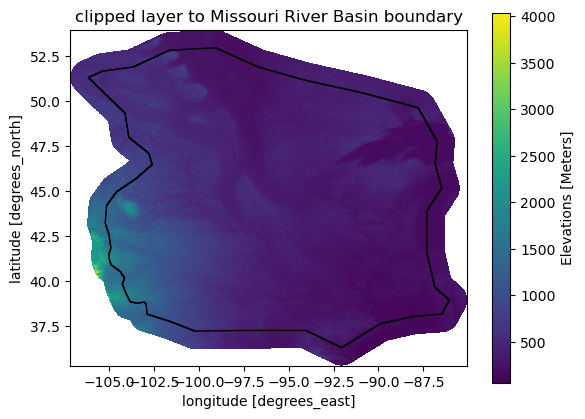

In [ ]:
#Plot clipped layer to make sure it looks correct
fig, ax = plt.subplots()
dem_buffered['Data'].plot(ax = ax)
gdf.plot(ax = ax, facecolor = 'None', edgecolor = 'k')
ax.set_title('clipped layer to Missouri River Basin boundary')
ax.set_aspect(1)

In [ ]:
krig_uk_dem = UniversalKriging(
    x=measurements["LONGITUDE"],   # x coordinates of gaging stations
    y=measurements["LATITUDE"],    # y coordinates of gaging stations
    z=measurements["D_SWE_OM"],    # SWE values at gaging stations
    drift_terms=['external_Z', 'specified'],  # Including external drift and specified drift terms
    external_drift=dem_2d,         # 2D array of DEM used for external drift
    external_drift_x=lons,         # x coordinates of DEM grid
    external_drift_y=lats,         # y coordinates of DEM grid
    specified_drift=[measurements['DEM_EL']]  # Elevation of gaging stations
)


### Reshape Data and Predict Grid

In [ ]:
#Create grid of longitudes and latitudes
lonsi, latsi = np.meshgrid(lons, lats)

# Flatten the arrays
x_pred = np.array(list(zip(lonsi.ravel(), latsi.ravel())))

# Align dimension names with our station data
dem_renamed = dem_buffered.rename({"x": "lon", "y": "lat"})

# Convert the DataArray to Pandas DataFrame
p_pred = dem_renamed.to_dataframe().reset_index()[["lon", "lat", "Data"]]

# Replace NaNs in p_pred["Data"] with zeros for the prediction step
p_pred["Data"].fillna(0, inplace=True)

p_pred

C:\Users\clemasters\AppData\Local\Temp\ipykernel_7636\218795877.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  p_pred["Data"].fillna(0, inplace=True)


,lon,lat,Data
0,-107.145833,53.979167,0.0
1,-107.137500,53.979167,0.0
2,-107.129167,53.979167,0.0
3,-107.120833,53.979167,0.0
4,-107.112500,53.979167,0.0
...,...,...,...
5946188,-85.095833,35.295833,0.0
5946189,-85.087500,35.295833,0.0
5946190,-85.079167,35.295833,0.0
5946191,-85.070833,35.295833,0.0


### Code for smaller regions (UMRB Region)

In [ ]:
# Perform the kriging
z, ss = krig_uk_dem.execute('points', x_pred[:, 0], x_pred[:, 1], specified_drift_arrays=[p_pred["Data"]], backend='loop')

# Reshape the results for plotting
z = z.reshape(lonsi.shape)
ss = ss.reshape(lonsi.shape)

# Plot the kriged values
plt.figure(figsize=(10, 8))
plt.imshow(z, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Interpolated values')
plt.title('Universal Kriging Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Plot the kriging variance
plt.figure(figsize=(10, 8))
plt.imshow(ss, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Kriging Variance')
plt.title('Kriging Variance')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Code for larger assimilation region (chunked code)

In [ ]:
# Function to process chunks
def process_chunk(chunk, p_pred_chunk):
    # Convert p_pred_chunk to a DataFrame to handle NaNs
    p_pred_df = pd.DataFrame(p_pred_chunk, columns=["lon", "lat", "Data"])
    
    # Perform kriging for the current chunk
    z_chunk, ss_chunk = krig_uk_dem.execute(
        'points', 
        chunk[:, 0], 
        chunk[:, 1], 
        specified_drift_arrays=[p_pred_df["Data"].to_numpy()]
    )
    
    # Return the kriged values and variances
    return z_chunk, ss_chunk

# Process data in chunks
chunk_size = 10000
num_chunks = len(x_pred) // chunk_size + 1

predicted_values = []
predicted_variances = []

for i in range(num_chunks):
    # Extract the chunk for x_pred
    chunk = x_pred[i * chunk_size:(i + 1) * chunk_size]
    
    # Extract the corresponding chunk for p_pred
    start_idx = i * chunk_size
    end_idx = min((i + 1) * chunk_size, len(p_pred))
    p_pred_chunk = p_pred.iloc[start_idx:end_idx].to_numpy()
    
    # Predict the values for the current chunk
    predicted_chunk, variance_chunk = process_chunk(chunk, p_pred_chunk)
    predicted_values.append(predicted_chunk)
    predicted_variances.append(variance_chunk)

# Combine results
predicted_values = np.concatenate(predicted_values).reshape(lonsi.shape)
predicted_variances = np.concatenate(predicted_variances).reshape(lonsi.shape)

# Plot the kriged values
plt.figure(figsize=(10, 8))
plt.imshow(predicted_values, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Interpolated values')
plt.title('Universal Kriging Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Plot the kriging variance
plt.figure(figsize=(10, 8))
plt.imshow(predicted_variances, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Kriging Variance')
plt.title('Kriging Variance')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Code below takes the predicted_da from the chunking code for larger datasets and clips to assimilation region

In [ ]:
# Convert predicted_values to an xarray DataArray
predicted_da = xr.DataArray(
    predicted_values,
    dims=["y", "x"],
    coords={"y": dem_region_clipped['y'].values, "x": dem_region_clipped['x'].values},
    name="predicted_values"
)

# Assign CRS
predicted_da = predicted_da.rio.write_crs("EPSG:4326")

#clip the model grid to the assimilation region
predicted_da = predicted_da.rio.clip(gdf.geometry)

predicted_da

In [ ]:
# Convert predicted_values to an xarray DataArray
predicted_var = xr.DataArray(
    predicted_variances,
    dims=["y", "x"],
    coords={"y": dem_region_clipped['y'].values, "x": dem_region_clipped['x'].values},
    name="predicted_values"
)

# Assign CRS
predicted_var = predicted_var.rio.write_crs("EPSG:4326")

#clip the model grid to the assimilation region
predicted_var = predicted_var.rio.clip(gdf.geometry)

predicted_var

In [ ]:
plt.figure(figsize=(16,9))
plt.imshow(predicted_da)
plt.colorbar()
plt.show()

In [ ]:
plt.figure(figsize=(16,9))
plt.imshow(predicted_var)
plt.colorbar()
plt.show()

This code saves the universal kriging nudging field layer withing the larger assimilation region

In [ ]:
predicted_da.rio.to_raster("universal_kriging_full_assimilation_with_UMRB_01_10_24.tif")

This code saves the universal kriging nudging fields variance withing the larger assimilation region

In [ ]:
predicted_var.rio.to_raster("universal_kriging_variance_full_assimilation_with_UMRB_01_10_24.tif")

## 12/11/22 Assimilation Universal Kriging (Using Elevation as drift) - without UMRB stations

### Load assimilation boundary layer and create polygon geodataframe to clip DEM

In [52]:
# Load assimilation region boundary
boundary = xr.open_dataset(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_with_umrb\ssm_process_region_2022121012_2022121112_swe_east.nc')

# Select the variable of interest
variable_name = 'Data'  # Replace with the actual variable name
data = boundary[variable_name]

# Create a boolean mask (e.g., mask for values greater than a threshold)
mask = data == 100

# Convert the mask to a numpy array
mask_array = mask.values

# Assuming the variable has 'lat' and 'lon' as dimensions
latitudes = data['lat'].values
longitudes = data['lon'].values

# Transform the mask array into polygons
polygons = []
transform = rasterio.transform.from_bounds(
    west=min(longitudes), 
    south=min(latitudes),
    east=max(longitudes), 
    north=max(latitudes), 
    width=mask_array.shape[1],
    height=mask_array.shape[0]
)

# Extract shapes where the mask is True (data == 100)
for geom, val in shapes(mask_array.astype(np.int32), mask=mask_array, transform=transform):
    if val == 1:  # If the condition is met (data == 100)
        polygons.append(shape(geom))


# Create a GeoDataFrame from the polygons
gdf = gpd.GeoDataFrame({'geometry': polygons}, crs='EPSG:4326')

# Print the GeoDataFrame to check the results
print(gdf)

                                            geometry
0  POLYGON ((-65.04544 49.44756, -65.04544 49.439...
1  POLYGON ((-103.64934 44.79036, -103.64934 44.7...
2  POLYGON ((-84.57653 45.80678, -84.57653 45.798...
3  POLYGON ((-109.13204 51.77199, -109.13204 51.7...


### Upload DEM and add elevation data to stations

In [53]:
# add DEM elevation to all stations that didn't have elevation data
#Path to your NetCDF file
file_path = r"C:\Repos\umrb-snodas\resources\Terrain_GMTED_2010_30sec.ea.nc"

# Open the dataset
dem = xr.open_dataset(file_path)

# Select a subset of the data
#precip_2022 = precip_2022.sel(day=slice('2022-10-01', '2022-12-31'))

# Compute the subset
dem = dem.compute()

dem

<xarray.Dataset> Size: 802MB
Dimensions:     (lat: 6960, lon: 14400, nv: 2)
Coordinates:
  * lat         (lat) float64 56kB 72.0 71.99 71.98 71.97 ... 14.02 14.01 14.0
  * lon         (lon) float64 115kB -170.0 -170.0 -170.0 ... -50.02 -50.01 -50.0
Dimensions without coordinates: nv
Data variables:
    lat_bounds  (lat, nv) float64 111kB 72.0 71.99 71.99 ... 14.01 14.01 14.0
    lon_bounds  (lon, nv) float64 230kB -170.0 -170.0 -170.0 ... -50.01 -50.0
    Data        (lat, lon) float64 802MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    crs         int32 4B -2147483647
Attributes:
    comment:         2013-08-29 09:46:55 UTC created comment: Not applicable\...
    history:         2013-08-29 09:46:55 UTC created by module: DEM_in_any\n2...
    format_version:  NOHRSC NetCDF raster file v1.2
    Conventions:     CF-1.6
    references:      Not applicable
    source:          Not applicable
    title:           Not applicable

In [54]:
# Load shapefile that contains stations and delta SWE from the 01/10/24 assimilation
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_with_umrb\ssm1054_md_based_2022121012_2022121112_east.shp"

# Load shapefile
measurements = gpd.read_file(shapefile_path)

# Drop all points that arent stations
measurements  = measurements [measurements ['VALUE'] != 1]

# Just keep the columns Latitude, Longitude, Station_id, station_ty, station_elevation, DEM_elevation, Forest_den, D_SWE_OM
# Keep only the specified columns
columns_to_keep = ['VALUE', 'LATITUDE', 'LONGITUDE', 'STATION_ID', 'STATION_TY', 'STATION_EL', 'DEM_ELEVAT', 'FOREST_DEN', 'MD_DEPTH_T','D_SWE_OM', 'OB_SWE', 'MD_SWE']

measurements  = measurements [columns_to_keep]

measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE
3042,NaN,46.993439,-65.506909,CAN-NB-11,COCORAHS,33.0,28.0,54.0,2022-12-11 09,0.000000,0.000000,0.000000
3043,NaN,47.289956,-68.411945,CAN-NB-134,COCORAHS,147.0,152.0,24.0,2022-12-11 12,-0.016242,0.000000,0.016242
3044,NaN,47.057010,-67.726300,CAN-NB-38,COCORAHS,200.0,180.0,18.0,2022-12-11 12,-0.012468,0.000000,0.012468
3045,NaN,46.868300,-68.013600,CAR,"ARSR4, ASOS, AWIPS, COOPAB, CRS, UA, WSR88D",187.0,184.0,14.0,2022-12-11 12,0.000000,0.000000,0.000000
3046,NaN,46.868100,-68.012500,CARM1,"COOPAB, SNOCOR",191.0,184.0,14.0,2022-12-11 12,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4136,NaN,44.088600,-103.299700,SD-PN-2,COCORAHS,1056.0,1052.0,17.0,2022-12-11 14,0.000000,0.000000,0.000000
4137,NaN,44.086570,-103.370100,SD-PN-40,COCORAHS,1282.0,1284.0,30.0,2022-12-11 14,0.000000,0.000000,0.000000
4138,NaN,44.497300,-103.871700,SPES2,COOPABC,1108.0,1108.0,9.0,2022-12-10 16,0.000000,0.000000,0.000000
4139,NaN,44.424500,-103.379300,STMS2,MESO-ST,987.0,985.0,1.0,2022-12-10 20,0.000102,0.000102,0.000000


In [55]:
# Initialize an empty list to store surface radiation
DEM_EL = []

# Extracting data based on lat, lon, and time from Dec_28_2023_stations
for index, (lat, lon) in measurements[['LATITUDE', 'LONGITUDE']].iterrows():

    DEM_values = dem.sel(lat=lat, lon=lon, method='nearest')['Data'].item()
    
    # Append wind speed to the list
    DEM_EL.append(DEM_values)

# Add 'wind_speed' column to Dec_28_2023_stations
measurements['DEM_EL'] = DEM_EL

# Display the updated DataFrame
measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE,DEM_EL
3042,NaN,46.993439,-65.506909,CAN-NB-11,COCORAHS,33.0,28.0,54.0,2022-12-11 09,0.000000,0.000000,0.000000,28.0
3043,NaN,47.289956,-68.411945,CAN-NB-134,COCORAHS,147.0,152.0,24.0,2022-12-11 12,-0.016242,0.000000,0.016242,152.0
3044,NaN,47.057010,-67.726300,CAN-NB-38,COCORAHS,200.0,180.0,18.0,2022-12-11 12,-0.012468,0.000000,0.012468,180.0
3045,NaN,46.868300,-68.013600,CAR,"ARSR4, ASOS, AWIPS, COOPAB, CRS, UA, WSR88D",187.0,184.0,14.0,2022-12-11 12,0.000000,0.000000,0.000000,184.0
3046,NaN,46.868100,-68.012500,CARM1,"COOPAB, SNOCOR",191.0,184.0,14.0,2022-12-11 12,0.000000,0.000000,0.000000,184.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4136,NaN,44.088600,-103.299700,SD-PN-2,COCORAHS,1056.0,1052.0,17.0,2022-12-11 14,0.000000,0.000000,0.000000,1052.0
4137,NaN,44.086570,-103.370100,SD-PN-40,COCORAHS,1282.0,1284.0,30.0,2022-12-11 14,0.000000,0.000000,0.000000,1284.0
4138,NaN,44.497300,-103.871700,SPES2,COOPABC,1108.0,1108.0,9.0,2022-12-10 16,0.000000,0.000000,0.000000,1108.0
4139,NaN,44.424500,-103.379300,STMS2,MESO-ST,987.0,985.0,1.0,2022-12-10 20,0.000102,0.000102,0.000000,985.0


### Create a list of all the UMRB station_id's and filter them out of dataframe

In [56]:
# Create a list of all UMRB Station names so you can remove from assimilation

# Read the CSV file
UMRB_ID = pd.read_csv(r'C:\Repos\umrb-snodas\resources\Current_UMRB_Station_List.csv')

# Create station ID List
UMRB_ID = UMRB_ID['station_id'].to_list()

# Filter the DataFrame
measurements = measurements[~measurements['STATION_ID'].isin(UMRB_ID)]

measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE,DEM_EL
3042,NaN,46.993439,-65.506909,CAN-NB-11,COCORAHS,33.0,28.0,54.0,2022-12-11 09,0.000000,0.00000,0.000000,28.0
3043,NaN,47.289956,-68.411945,CAN-NB-134,COCORAHS,147.0,152.0,24.0,2022-12-11 12,-0.016242,0.00000,0.016242,152.0
3044,NaN,47.057010,-67.726300,CAN-NB-38,COCORAHS,200.0,180.0,18.0,2022-12-11 12,-0.012468,0.00000,0.012468,180.0
3045,NaN,46.868300,-68.013600,CAR,"ARSR4, ASOS, AWIPS, COOPAB, CRS, UA, WSR88D",187.0,184.0,14.0,2022-12-11 12,0.000000,0.00000,0.000000,184.0
3046,NaN,46.868100,-68.012500,CARM1,"COOPAB, SNOCOR",191.0,184.0,14.0,2022-12-11 12,0.000000,0.00000,0.000000,184.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4135,NaN,44.278060,-103.809200,SD-LW-6,COCORAHS,1798.0,1832.0,43.0,2022-12-11 14,0.041137,0.04898,0.007843,1832.0
4136,NaN,44.088600,-103.299700,SD-PN-2,COCORAHS,1056.0,1052.0,17.0,2022-12-11 14,0.000000,0.00000,0.000000,1052.0
4137,NaN,44.086570,-103.370100,SD-PN-40,COCORAHS,1282.0,1284.0,30.0,2022-12-11 14,0.000000,0.00000,0.000000,1284.0
4138,NaN,44.497300,-103.871700,SPES2,COOPABC,1108.0,1108.0,9.0,2022-12-10 16,0.000000,0.00000,0.000000,1108.0


### Load DEM and Station Data

In [57]:
# Load high-resolution DEM with xarray.open_rasterio
dem = xr.open_dataset(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\Terrain_GMTED_2010_30sec.ea.nc')

dem = dem.rio.write_crs('WGS84')

# If dimensions are not 'x' and 'y', set them explicitly
dem = dem.rio.set_spatial_dims("lon", "lat", inplace=True)

dem = dem.rename({'lon': 'x', 'lat': 'y'})

# Drop 'lat_bounds' and 'lon_bounds' variables
dem = dem.drop_vars(['lat_bounds', 'lon_bounds'])

dem_region_clipped = dem.rio.clip(gdf.geometry, gdf.crs)

# Create a buffer around the geometry
buffer_distance = 1.0  # Adjust this distance as needed (in degrees, meters, etc. depending on your CRS)
gdf_buffered = gdf.copy()
gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(buffer_distance)

# Clip the DEM with the buffered geometry
dem_buffered = dem.rio.clip(gdf_buffered.geometry, gdf_buffered.crs)


#Extract and convert coordinates to lists
lons = dem_buffered['x'].values
lats = dem_buffered['y'].values

# Convert the clipped DEM data array to a 2D array
dem_2d = dem_buffered.to_array().isel(variable=0).values

# Replace all NaN values with zero
dem_2d = np.nan_to_num(dem_2d, nan=0.0)

C:\Users\clemasters\AppData\Local\Temp\ipykernel_7636\2895085862.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(buffer_distance)


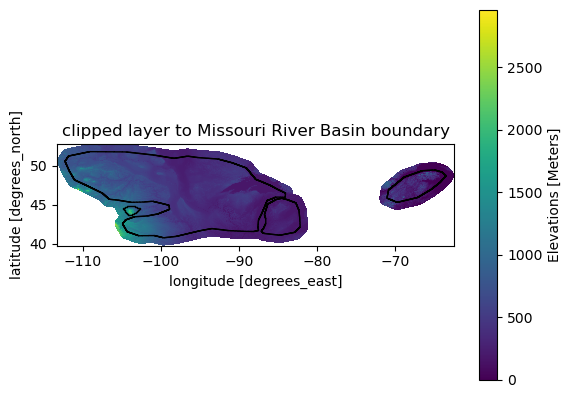

In [58]:
#Plot clipped layer to make sure it looks correct
fig, ax = plt.subplots()
dem_buffered['Data'].plot(ax = ax)
gdf.plot(ax = ax, facecolor = 'None', edgecolor = 'k')
ax.set_title('clipped layer to Missouri River Basin boundary')
ax.set_aspect(1)

In [59]:
krig_uk_dem = UniversalKriging(
    x=measurements["LONGITUDE"],   # x coordinates of gaging stations
    y=measurements["LATITUDE"],    # y coordinates of gaging stations
    z=measurements["D_SWE_OM"],    # SWE values at gaging stations
    drift_terms=['external_Z', 'specified'],  # Including external drift and specified drift terms
    external_drift=dem_2d,         # 2D array of DEM used for external drift
    external_drift_x=lons,         # x coordinates of DEM grid
    external_drift_y=lats,         # y coordinates of DEM grid
    specified_drift=[measurements['DEM_EL']]  # Elevation of gaging stations
)


### Reshape Data and Predict Grid

In [60]:
#Create grid of longitudes and latitudes
lonsi, latsi = np.meshgrid(lons, lats)

# Flatten the arrays
x_pred = np.array(list(zip(lonsi.ravel(), latsi.ravel())))

# Align dimension names with our station data
dem_renamed = dem_buffered.rename({"x": "lon", "y": "lat"})

# Convert the DataArray to Pandas DataFrame
p_pred = dem_renamed.to_dataframe().reset_index()[["lon", "lat", "Data"]]

# Replace NaNs in p_pred["Data"] with zeros for the prediction step
p_pred["Data"].fillna(0, inplace=True)

p_pred

C:\Users\clemasters\AppData\Local\Temp\ipykernel_7636\218795877.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  p_pred["Data"].fillna(0, inplace=True)


,lon,lat,Data
0,-113.270833,52.770833,0.0
1,-113.262500,52.770833,0.0
2,-113.254167,52.770833,0.0
3,-113.245833,52.770833,0.0
4,-113.237500,52.770833,0.0
...,...,...,...
9514137,-62.554167,39.762500,0.0
9514138,-62.545833,39.762500,0.0
9514139,-62.537500,39.762500,0.0
9514140,-62.529167,39.762500,0.0


### Code for smaller regions (UMRB Region)

In [ ]:
# Perform the kriging
z, ss = krig_uk_dem.execute('points', x_pred[:, 0], x_pred[:, 1], specified_drift_arrays=[p_pred["Data"]], backend='loop')

# Reshape the results for plotting
z = z.reshape(lonsi.shape)
ss = ss.reshape(lonsi.shape)

# Plot the kriged values
plt.figure(figsize=(10, 8))
plt.imshow(z, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Interpolated values')
plt.title('Universal Kriging Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Plot the kriging variance
plt.figure(figsize=(10, 8))
plt.imshow(ss, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Kriging Variance')
plt.title('Kriging Variance')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Code for larger assimilation region (chunked code)

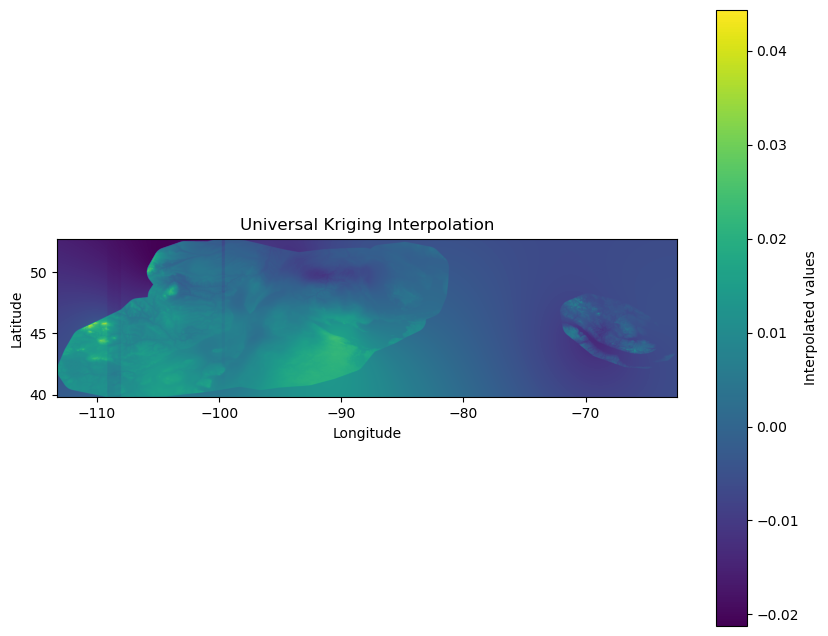

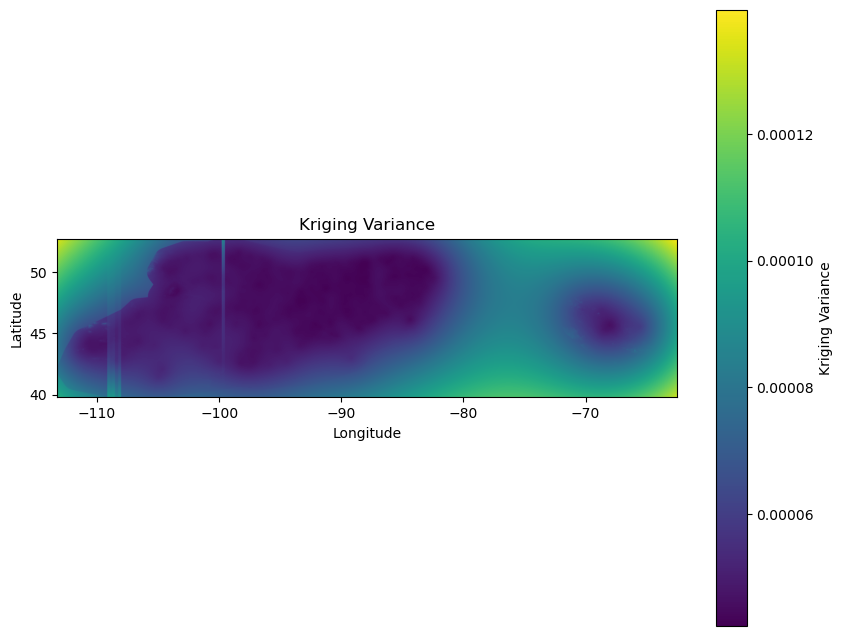

In [61]:
# Function to process chunks
def process_chunk(chunk, p_pred_chunk):
    # Convert p_pred_chunk to a DataFrame to handle NaNs
    p_pred_df = pd.DataFrame(p_pred_chunk, columns=["lon", "lat", "Data"])
    
    # Perform kriging for the current chunk
    z_chunk, ss_chunk = krig_uk_dem.execute(
        'points', 
        chunk[:, 0], 
        chunk[:, 1], 
        specified_drift_arrays=[p_pred_df["Data"].to_numpy()]
    )
    
    # Return the kriged values and variances
    return z_chunk, ss_chunk

# Process data in chunks
chunk_size = 10000
num_chunks = len(x_pred) // chunk_size + 1

predicted_values = []
predicted_variances = []

for i in range(num_chunks):
    # Extract the chunk for x_pred
    chunk = x_pred[i * chunk_size:(i + 1) * chunk_size]
    
    # Extract the corresponding chunk for p_pred
    start_idx = i * chunk_size
    end_idx = min((i + 1) * chunk_size, len(p_pred))
    p_pred_chunk = p_pred.iloc[start_idx:end_idx].to_numpy()
    
    # Predict the values for the current chunk
    predicted_chunk, variance_chunk = process_chunk(chunk, p_pred_chunk)
    predicted_values.append(predicted_chunk)
    predicted_variances.append(variance_chunk)

# Combine results
predicted_values = np.concatenate(predicted_values).reshape(lonsi.shape)
predicted_variances = np.concatenate(predicted_variances).reshape(lonsi.shape)

# Plot the kriged values
plt.figure(figsize=(10, 8))
plt.imshow(predicted_values, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Interpolated values')
plt.title('Universal Kriging Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Plot the kriging variance
plt.figure(figsize=(10, 8))
plt.imshow(predicted_variances, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Kriging Variance')
plt.title('Kriging Variance')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Code below takes the predicted_da from the chunking code for larger datasets and clips to assimilation region

In [63]:
# Convert predicted_values to an xarray DataArray
predicted_da = xr.DataArray(
    predicted_values,
    dims=["y", "x"],
    coords={"y": dem_buffered['y'].values, "x": dem_buffered['x'].values},
    name="predicted_values"
)

# Assign CRS
predicted_da = predicted_da.rio.write_crs("EPSG:4326")

#clip the model grid to the assimilation region
predicted_da = predicted_da.rio.clip(gdf.geometry)

predicted_da

<xarray.DataArray 'predicted_values' (y: 1322, x: 5851)> Size: 62MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y            (y) float64 11kB 51.77 51.76 51.75 51.75 ... 40.78 40.77 40.76
  * x            (x) float64 47kB -112.3 -112.3 -112.3 ... -63.54 -63.53 -63.52
    spatial_ref  int32 4B 0

In [64]:
# Convert predicted_values to an xarray DataArray
predicted_var = xr.DataArray(
    predicted_variances,
    dims=["y", "x"],
    coords={"y": dem_buffered['y'].values, "x": dem_buffered['x'].values},
    name="predicted_values"
)

# Assign CRS
predicted_var = predicted_var.rio.write_crs("EPSG:4326")

#clip the model grid to the assimilation region
predicted_var = predicted_var.rio.clip(gdf.geometry)

predicted_var

<xarray.DataArray 'predicted_values' (y: 1322, x: 5851)> Size: 62MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y            (y) float64 11kB 51.77 51.76 51.75 51.75 ... 40.78 40.77 40.76
  * x            (x) float64 47kB -112.3 -112.3 -112.3 ... -63.54 -63.53 -63.52
    spatial_ref  int32 4B 0

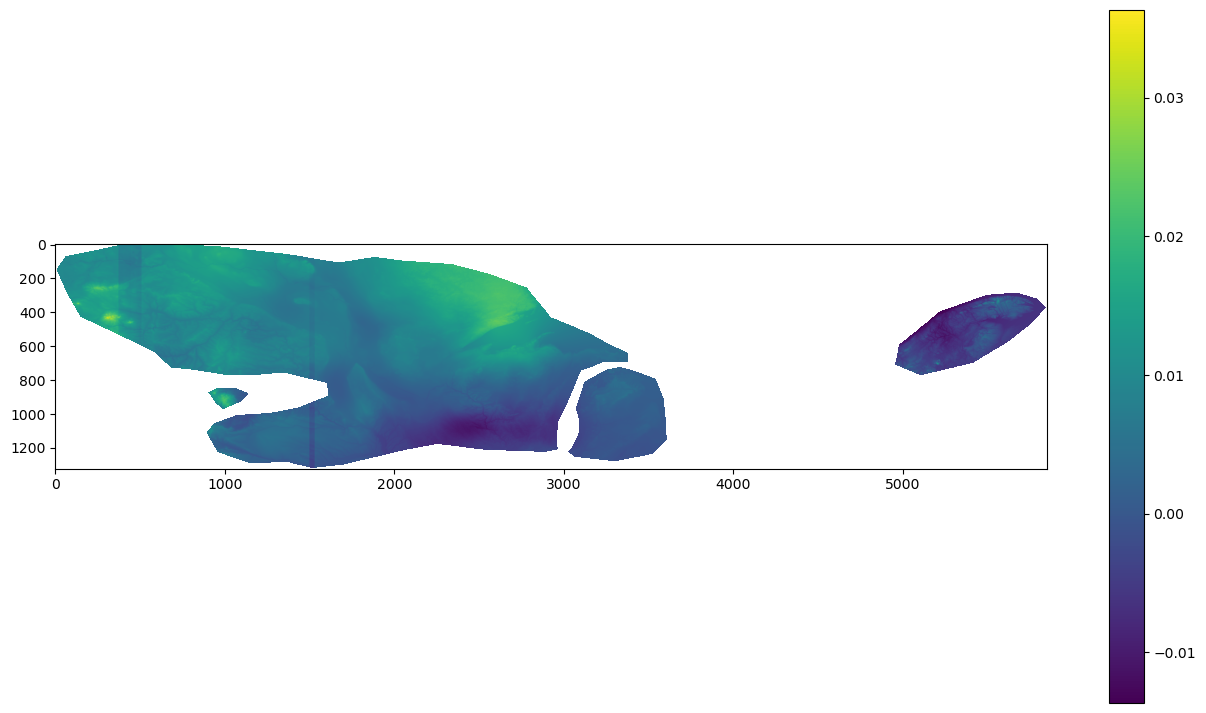

In [65]:
plt.figure(figsize=(16,9))
plt.imshow(predicted_da)
plt.colorbar()
plt.show()

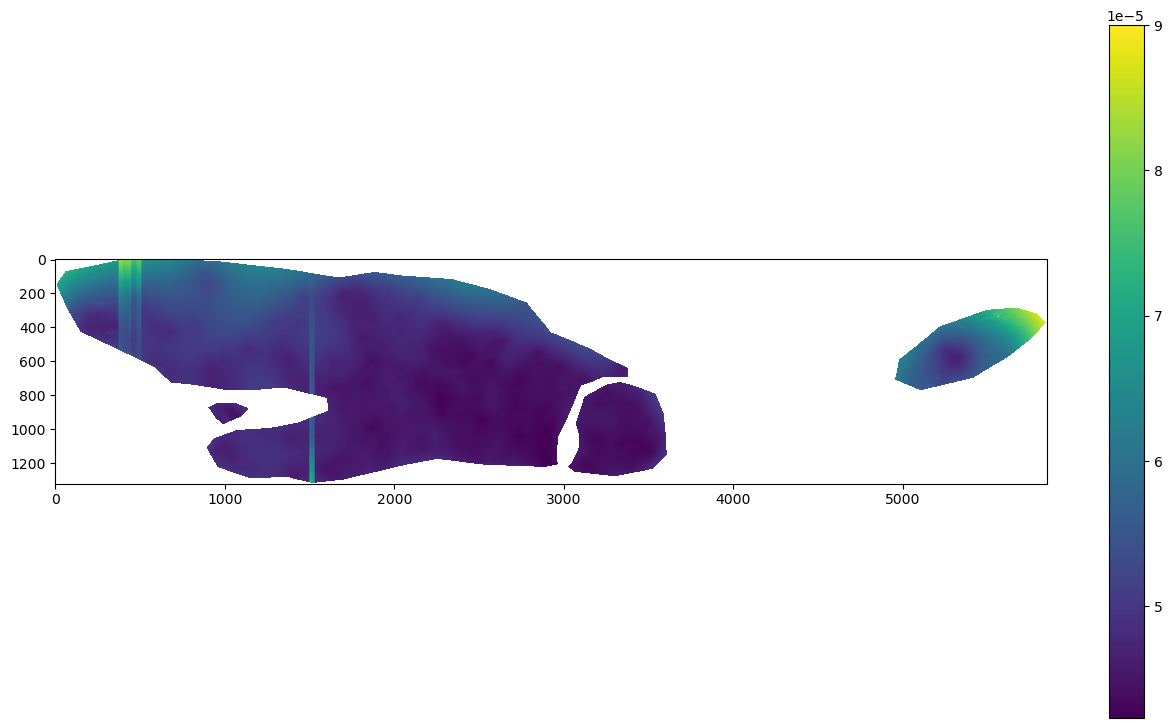

In [66]:
plt.figure(figsize=(16,9))
plt.imshow(predicted_var)
plt.colorbar()
plt.show()

This code saves the universal kriging nudging field layer withing the larger assimilation region

In [67]:
predicted_da.rio.to_raster("universal_kriging_full_assimilation_without_UMRB_12_11_22.tif")

This code saves the universal kriging nudging fields variance withing the larger assimilation region

In [68]:
predicted_var.rio.to_raster("universal_kriging_variance_full_assimilation_without_UMRB_12_11_22.tif")

## 12/11/22 Assimilation Universal Kriging (Using Elevation as drift) - with UMRB stations

### Load assimilation boundary layer and create polygon geodataframe to clip DEM

In [69]:
# Load assimilation region boundary
boundary = xr.open_dataset(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_with_umrb\ssm_process_region_2022121012_2022121112_swe_east.nc')

# Select the variable of interest
variable_name = 'Data'  # Replace with the actual variable name
data = boundary[variable_name]

# Create a boolean mask (e.g., mask for values greater than a threshold)
mask = data == 100

# Convert the mask to a numpy array
mask_array = mask.values

# Assuming the variable has 'lat' and 'lon' as dimensions
latitudes = data['lat'].values
longitudes = data['lon'].values

# Transform the mask array into polygons
polygons = []
transform = rasterio.transform.from_bounds(
    west=min(longitudes), 
    south=min(latitudes),
    east=max(longitudes), 
    north=max(latitudes), 
    width=mask_array.shape[1],
    height=mask_array.shape[0]
)

# Extract shapes where the mask is True (data == 100)
for geom, val in shapes(mask_array.astype(np.int32), mask=mask_array, transform=transform):
    if val == 1:  # If the condition is met (data == 100)
        polygons.append(shape(geom))


# Create a GeoDataFrame from the polygons
gdf = gpd.GeoDataFrame({'geometry': polygons}, crs='EPSG:4326')

# Print the GeoDataFrame to check the results
print(gdf)

                                            geometry
0  POLYGON ((-65.04544 49.44756, -65.04544 49.439...
1  POLYGON ((-103.64934 44.79036, -103.64934 44.7...
2  POLYGON ((-84.57653 45.80678, -84.57653 45.798...
3  POLYGON ((-109.13204 51.77199, -109.13204 51.7...


### Upload DEM and add elevation data to stations

In [70]:
# add DEM elevation to all stations that didn't have elevation data
#Path to your NetCDF file
file_path = r"C:\Repos\umrb-snodas\resources\Terrain_GMTED_2010_30sec.ea.nc"

# Open the dataset
dem = xr.open_dataset(file_path)

# Select a subset of the data
#precip_2022 = precip_2022.sel(day=slice('2022-10-01', '2022-12-31'))

# Compute the subset
dem = dem.compute()

dem

<xarray.Dataset> Size: 802MB
Dimensions:     (lat: 6960, lon: 14400, nv: 2)
Coordinates:
  * lat         (lat) float64 56kB 72.0 71.99 71.98 71.97 ... 14.02 14.01 14.0
  * lon         (lon) float64 115kB -170.0 -170.0 -170.0 ... -50.02 -50.01 -50.0
Dimensions without coordinates: nv
Data variables:
    lat_bounds  (lat, nv) float64 111kB 72.0 71.99 71.99 ... 14.01 14.01 14.0
    lon_bounds  (lon, nv) float64 230kB -170.0 -170.0 -170.0 ... -50.01 -50.0
    Data        (lat, lon) float64 802MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    crs         int32 4B -2147483647
Attributes:
    comment:         2013-08-29 09:46:55 UTC created comment: Not applicable\...
    history:         2013-08-29 09:46:55 UTC created by module: DEM_in_any\n2...
    format_version:  NOHRSC NetCDF raster file v1.2
    Conventions:     CF-1.6
    references:      Not applicable
    source:          Not applicable
    title:           Not applicable

In [71]:
# Load shapefile that contains stations and delta SWE from the 01/10/24 assimilation
shapefile_path = r"C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Test_Runs\12_11_22_Assimilations\snodas_assim_20221211_with_umrb\ssm1054_md_based_2022121012_2022121112_east.shp"

# Load shapefile
measurements = gpd.read_file(shapefile_path)

# Drop all points that arent stations
measurements  = measurements [measurements ['VALUE'] != 1]

# Just keep the columns Latitude, Longitude, Station_id, station_ty, station_elevation, DEM_elevation, Forest_den, D_SWE_OM
# Keep only the specified columns
columns_to_keep = ['VALUE', 'LATITUDE', 'LONGITUDE', 'STATION_ID', 'STATION_TY', 'STATION_EL', 'DEM_ELEVAT', 'FOREST_DEN', 'MD_DEPTH_T','D_SWE_OM', 'OB_SWE', 'MD_SWE']

measurements  = measurements [columns_to_keep]

measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE
3042,NaN,46.993439,-65.506909,CAN-NB-11,COCORAHS,33.0,28.0,54.0,2022-12-11 09,0.000000,0.000000,0.000000
3043,NaN,47.289956,-68.411945,CAN-NB-134,COCORAHS,147.0,152.0,24.0,2022-12-11 12,-0.016242,0.000000,0.016242
3044,NaN,47.057010,-67.726300,CAN-NB-38,COCORAHS,200.0,180.0,18.0,2022-12-11 12,-0.012468,0.000000,0.012468
3045,NaN,46.868300,-68.013600,CAR,"ARSR4, ASOS, AWIPS, COOPAB, CRS, UA, WSR88D",187.0,184.0,14.0,2022-12-11 12,0.000000,0.000000,0.000000
3046,NaN,46.868100,-68.012500,CARM1,"COOPAB, SNOCOR",191.0,184.0,14.0,2022-12-11 12,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
4136,NaN,44.088600,-103.299700,SD-PN-2,COCORAHS,1056.0,1052.0,17.0,2022-12-11 14,0.000000,0.000000,0.000000
4137,NaN,44.086570,-103.370100,SD-PN-40,COCORAHS,1282.0,1284.0,30.0,2022-12-11 14,0.000000,0.000000,0.000000
4138,NaN,44.497300,-103.871700,SPES2,COOPABC,1108.0,1108.0,9.0,2022-12-10 16,0.000000,0.000000,0.000000
4139,NaN,44.424500,-103.379300,STMS2,MESO-ST,987.0,985.0,1.0,2022-12-10 20,0.000102,0.000102,0.000000


In [72]:
# Initialize an empty list to store surface radiation
DEM_EL = []

# Extracting data based on lat, lon, and time from Dec_28_2023_stations
for index, (lat, lon) in measurements[['LATITUDE', 'LONGITUDE']].iterrows():

    DEM_values = dem.sel(lat=lat, lon=lon, method='nearest')['Data'].item()
    
    # Append wind speed to the list
    DEM_EL.append(DEM_values)

# Add 'wind_speed' column to Dec_28_2023_stations
measurements['DEM_EL'] = DEM_EL

# Display the updated DataFrame
measurements

,VALUE,LATITUDE,LONGITUDE,STATION_ID,STATION_TY,STATION_EL,DEM_ELEVAT,FOREST_DEN,MD_DEPTH_T,D_SWE_OM,OB_SWE,MD_SWE,DEM_EL
3042,NaN,46.993439,-65.506909,CAN-NB-11,COCORAHS,33.0,28.0,54.0,2022-12-11 09,0.000000,0.000000,0.000000,28.0
3043,NaN,47.289956,-68.411945,CAN-NB-134,COCORAHS,147.0,152.0,24.0,2022-12-11 12,-0.016242,0.000000,0.016242,152.0
3044,NaN,47.057010,-67.726300,CAN-NB-38,COCORAHS,200.0,180.0,18.0,2022-12-11 12,-0.012468,0.000000,0.012468,180.0
3045,NaN,46.868300,-68.013600,CAR,"ARSR4, ASOS, AWIPS, COOPAB, CRS, UA, WSR88D",187.0,184.0,14.0,2022-12-11 12,0.000000,0.000000,0.000000,184.0
3046,NaN,46.868100,-68.012500,CARM1,"COOPAB, SNOCOR",191.0,184.0,14.0,2022-12-11 12,0.000000,0.000000,0.000000,184.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4136,NaN,44.088600,-103.299700,SD-PN-2,COCORAHS,1056.0,1052.0,17.0,2022-12-11 14,0.000000,0.000000,0.000000,1052.0
4137,NaN,44.086570,-103.370100,SD-PN-40,COCORAHS,1282.0,1284.0,30.0,2022-12-11 14,0.000000,0.000000,0.000000,1284.0
4138,NaN,44.497300,-103.871700,SPES2,COOPABC,1108.0,1108.0,9.0,2022-12-10 16,0.000000,0.000000,0.000000,1108.0
4139,NaN,44.424500,-103.379300,STMS2,MESO-ST,987.0,985.0,1.0,2022-12-10 20,0.000102,0.000102,0.000000,985.0


### Load DEM and Station Data

In [73]:
# Load high-resolution DEM with xarray.open_rasterio
dem = xr.open_dataset(r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\Terrain_GMTED_2010_30sec.ea.nc')

dem = dem.rio.write_crs('WGS84')

# If dimensions are not 'x' and 'y', set them explicitly
dem = dem.rio.set_spatial_dims("lon", "lat", inplace=True)

dem = dem.rename({'lon': 'x', 'lat': 'y'})

# Drop 'lat_bounds' and 'lon_bounds' variables
dem = dem.drop_vars(['lat_bounds', 'lon_bounds'])

dem_region_clipped = dem.rio.clip(gdf.geometry, gdf.crs)

# Create a buffer around the geometry
buffer_distance = 1.0  # Adjust this distance as needed (in degrees, meters, etc. depending on your CRS)
gdf_buffered = gdf.copy()
gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(buffer_distance)

# Clip the DEM with the buffered geometry
dem_buffered = dem.rio.clip(gdf_buffered.geometry, gdf_buffered.crs)


#Extract and convert coordinates to lists
lons = dem_buffered['x'].values
lats = dem_buffered['y'].values

# Convert the clipped DEM data array to a 2D array
dem_2d = dem_buffered.to_array().isel(variable=0).values

# Replace all NaN values with zero
dem_2d = np.nan_to_num(dem_2d, nan=0.0)

C:\Users\clemasters\AppData\Local\Temp\ipykernel_7636\2895085862.py:19: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buffered['geometry'] = gdf_buffered.geometry.buffer(buffer_distance)


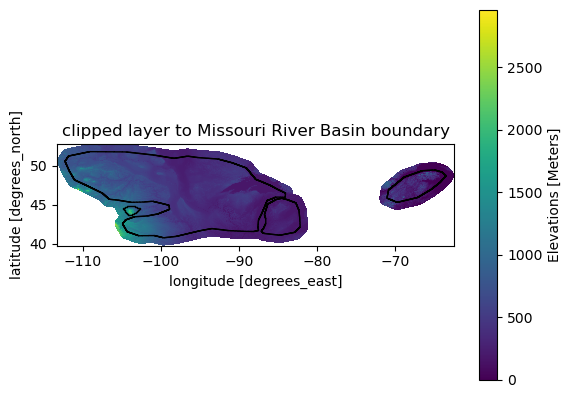

In [74]:
#Plot clipped layer to make sure it looks correct
fig, ax = plt.subplots()
dem_buffered['Data'].plot(ax = ax)
gdf.plot(ax = ax, facecolor = 'None', edgecolor = 'k')
ax.set_title('clipped layer to Missouri River Basin boundary')
ax.set_aspect(1)

In [75]:
krig_uk_dem = UniversalKriging(
    x=measurements["LONGITUDE"],   # x coordinates of gaging stations
    y=measurements["LATITUDE"],    # y coordinates of gaging stations
    z=measurements["D_SWE_OM"],    # SWE values at gaging stations
    drift_terms=['external_Z', 'specified'],  # Including external drift and specified drift terms
    external_drift=dem_2d,         # 2D array of DEM used for external drift
    external_drift_x=lons,         # x coordinates of DEM grid
    external_drift_y=lats,         # y coordinates of DEM grid
    specified_drift=[measurements['DEM_EL']]  # Elevation of gaging stations
)

### Reshape Data and Predict Grid

In [76]:
#Create grid of longitudes and latitudes
lonsi, latsi = np.meshgrid(lons, lats)

# Flatten the arrays
x_pred = np.array(list(zip(lonsi.ravel(), latsi.ravel())))

# Align dimension names with our station data
dem_renamed = dem_buffered.rename({"x": "lon", "y": "lat"})

# Convert the DataArray to Pandas DataFrame
p_pred = dem_renamed.to_dataframe().reset_index()[["lon", "lat", "Data"]]

# Replace NaNs in p_pred["Data"] with zeros for the prediction step
p_pred["Data"].fillna(0, inplace=True)

p_pred

C:\Users\clemasters\AppData\Local\Temp\ipykernel_7636\218795877.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  p_pred["Data"].fillna(0, inplace=True)


,lon,lat,Data
0,-113.270833,52.770833,0.0
1,-113.262500,52.770833,0.0
2,-113.254167,52.770833,0.0
3,-113.245833,52.770833,0.0
4,-113.237500,52.770833,0.0
...,...,...,...
9514137,-62.554167,39.762500,0.0
9514138,-62.545833,39.762500,0.0
9514139,-62.537500,39.762500,0.0
9514140,-62.529167,39.762500,0.0


### Code for smaller regions (UMRB Region)

In [ ]:
# Perform the kriging
z, ss = krig_uk_dem.execute('points', x_pred[:, 0], x_pred[:, 1], specified_drift_arrays=[p_pred["Data"]], backend='loop')

# Reshape the results for plotting
z = z.reshape(lonsi.shape)
ss = ss.reshape(lonsi.shape)

# Plot the kriged values
plt.figure(figsize=(10, 8))
plt.imshow(z, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Interpolated values')
plt.title('Universal Kriging Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Plot the kriging variance
plt.figure(figsize=(10, 8))
plt.imshow(ss, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Kriging Variance')
plt.title('Kriging Variance')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Code for larger assimilation region (chunked code)

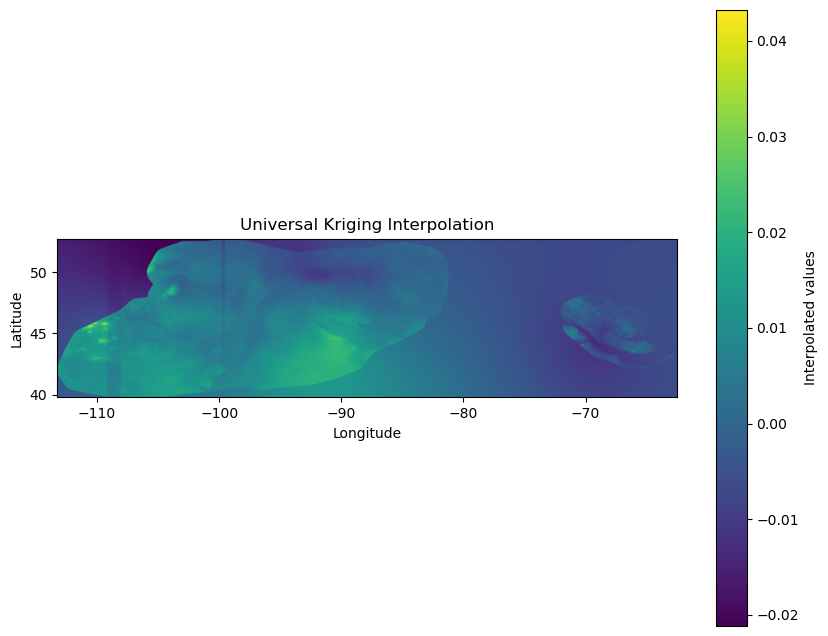

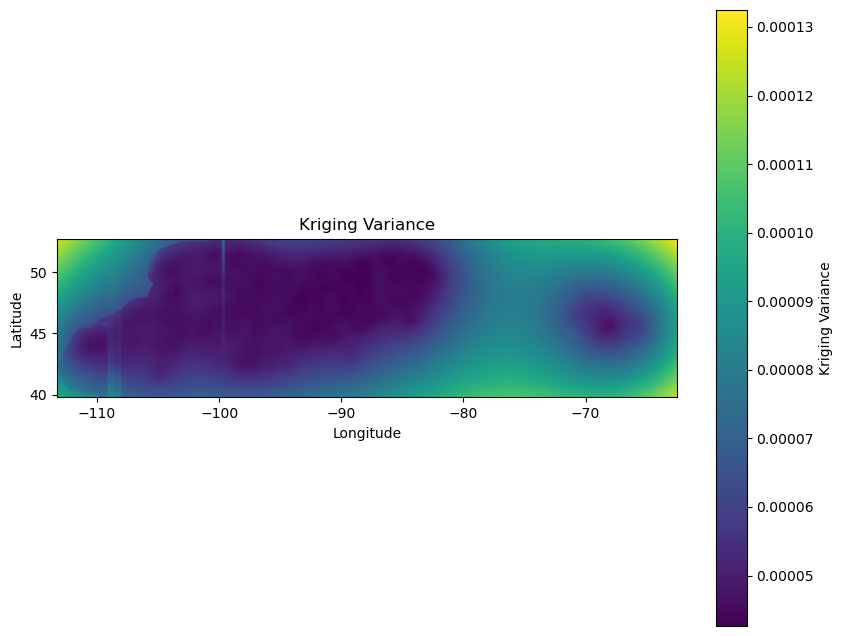

In [77]:
# Function to process chunks
def process_chunk(chunk, p_pred_chunk):
    # Convert p_pred_chunk to a DataFrame to handle NaNs
    p_pred_df = pd.DataFrame(p_pred_chunk, columns=["lon", "lat", "Data"])
    
    # Perform kriging for the current chunk
    z_chunk, ss_chunk = krig_uk_dem.execute(
        'points', 
        chunk[:, 0], 
        chunk[:, 1], 
        specified_drift_arrays=[p_pred_df["Data"].to_numpy()]
    )
    
    # Return the kriged values and variances
    return z_chunk, ss_chunk

# Process data in chunks
chunk_size = 10000
num_chunks = len(x_pred) // chunk_size + 1

predicted_values = []
predicted_variances = []

for i in range(num_chunks):
    # Extract the chunk for x_pred
    chunk = x_pred[i * chunk_size:(i + 1) * chunk_size]
    
    # Extract the corresponding chunk for p_pred
    start_idx = i * chunk_size
    end_idx = min((i + 1) * chunk_size, len(p_pred))
    p_pred_chunk = p_pred.iloc[start_idx:end_idx].to_numpy()
    
    # Predict the values for the current chunk
    predicted_chunk, variance_chunk = process_chunk(chunk, p_pred_chunk)
    predicted_values.append(predicted_chunk)
    predicted_variances.append(variance_chunk)

# Combine results
predicted_values = np.concatenate(predicted_values).reshape(lonsi.shape)
predicted_variances = np.concatenate(predicted_variances).reshape(lonsi.shape)

# Plot the kriged values
plt.figure(figsize=(10, 8))
plt.imshow(predicted_values, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Interpolated values')
plt.title('Universal Kriging Interpolation')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Plot the kriging variance
plt.figure(figsize=(10, 8))
plt.imshow(predicted_variances, extent=(np.min(lons), np.max(lons), np.min(lats), np.max(lats)), origin='lower')
plt.colorbar(label='Kriging Variance')
plt.title('Kriging Variance')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Code below takes the predicted_da from the chunking code for larger datasets and clips to assimilation region

In [79]:
# Convert predicted_values to an xarray DataArray
predicted_da = xr.DataArray(
    predicted_values,
    dims=["y", "x"],
    coords={"y": dem_buffered['y'].values, "x": dem_buffered['x'].values},
    name="predicted_values"
)

# Assign CRS
predicted_da = predicted_da.rio.write_crs("EPSG:4326")

#clip the model grid to the assimilation region
predicted_da = predicted_da.rio.clip(gdf.geometry)

predicted_da

<xarray.DataArray 'predicted_values' (y: 1322, x: 5851)> Size: 62MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y            (y) float64 11kB 51.77 51.76 51.75 51.75 ... 40.78 40.77 40.76
  * x            (x) float64 47kB -112.3 -112.3 -112.3 ... -63.54 -63.53 -63.52
    spatial_ref  int32 4B 0

In [80]:
# Convert predicted_values to an xarray DataArray
predicted_var = xr.DataArray(
    predicted_variances,
    dims=["y", "x"],
    coords={"y": dem_buffered['y'].values, "x": dem_buffered['x'].values},
    name="predicted_values"
)

# Assign CRS
predicted_var = predicted_var.rio.write_crs("EPSG:4326")

#clip the model grid to the assimilation region
predicted_var = predicted_var.rio.clip(gdf.geometry)

predicted_var

<xarray.DataArray 'predicted_values' (y: 1322, x: 5851)> Size: 62MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y            (y) float64 11kB 51.77 51.76 51.75 51.75 ... 40.78 40.77 40.76
  * x            (x) float64 47kB -112.3 -112.3 -112.3 ... -63.54 -63.53 -63.52
    spatial_ref  int32 4B 0

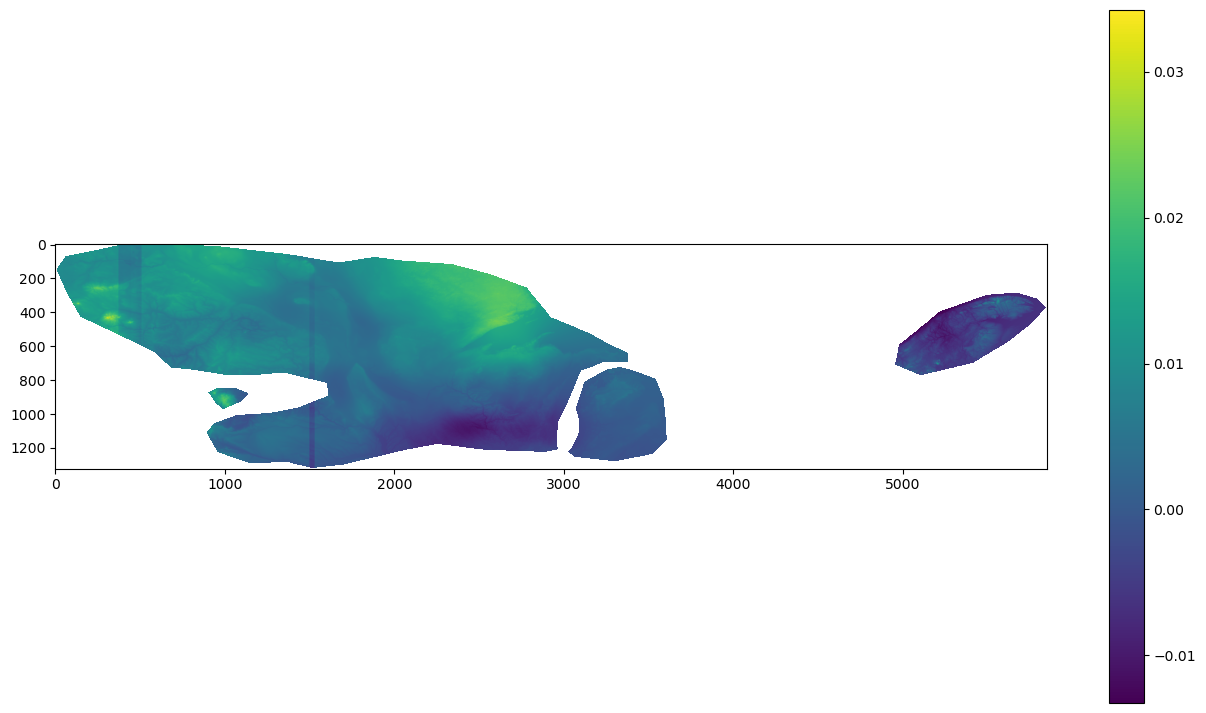

In [81]:
plt.figure(figsize=(16,9))
plt.imshow(predicted_da)
plt.colorbar()
plt.show()

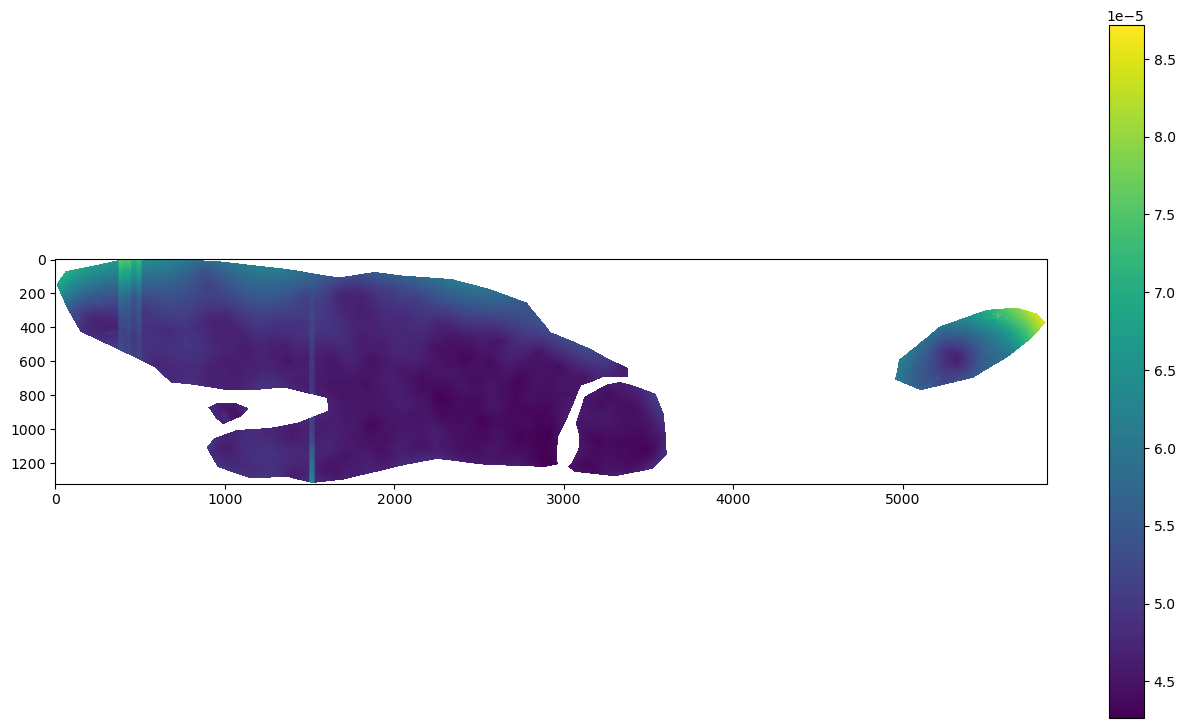

In [82]:
plt.figure(figsize=(16,9))
plt.imshow(predicted_var)
plt.colorbar()
plt.show()

This code saves the universal kriging nudging field layer withing the larger assimilation region

In [83]:
predicted_da.rio.to_raster("universal_kriging_full_assimilation_with_UMRB_12_11_22.tif")

This code saves the universal kriging nudging fields variance withing the larger assimilation region

In [84]:
predicted_var.rio.to_raster("universal_kriging_variance_full_assimilation_with_UMRB_12_11_22.tif")

## Function to create comparison map of different interpolations

In [5]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def create_difference_map(tif1_path, tif2_path, output_path):
    # Open the first TIF file
    with rasterio.open(tif1_path) as src1:
        tif1_data = src1.read(1)
        profile = src1.profile

    # Open the second TIF file
    with rasterio.open(tif2_path) as src2:
        tif2_data = src2.read(1)

    # Ensure both rasters have the same shape
    if tif1_data.shape != tif2_data.shape:
        raise ValueError("The input TIF files do not have the same dimensions.")

    # Calculate the difference
    difference = tif1_data - tif2_data

    # Update the profile for the difference raster
    profile.update(dtype=rasterio.float32)

    # Write the difference raster to a new file
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(difference.astype(rasterio.float32), 1)

    # Plot the difference map
    plt.figure(figsize=(10, 6))
    plt.imshow(difference, cmap='RdBu', vmin=-np.max(np.abs(difference)), vmax=np.max(np.abs(difference)))
    plt.colorbar(label='Difference')
    plt.title('Difference Map')
    plt.xlabel('Column #')
    plt.ylabel('Row #')
    plt.show()

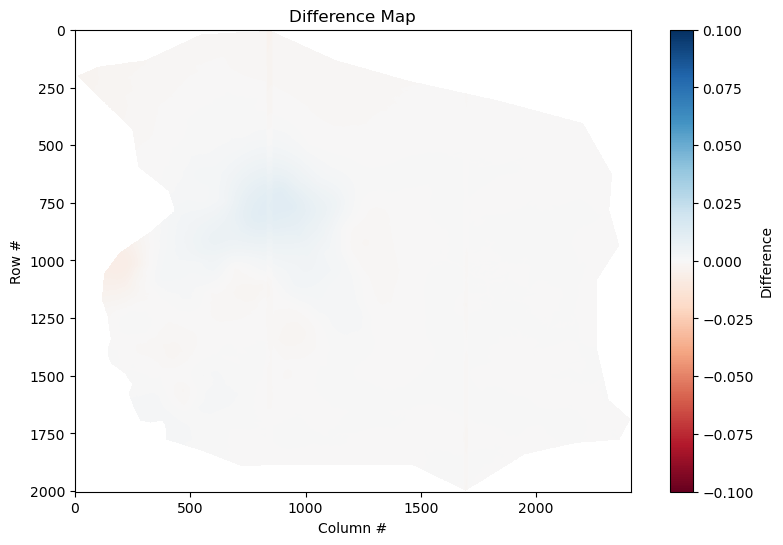

In [17]:
# Paths to the input TIF files and output difference map
tif1_path = r'C:\Repos\umrb-snodas\src\universal_kriging_full_assimilation_with_UMRB_12_28_23.tif'
tif2_path = r'C:\Repos\umrb-snodas\src\universal_kriging_full_assimilation_without_UMRB_12_28_23.tif'
output_path = 'difference_map.tif'

# Create the difference map
create_difference_map(tif1_path, tif2_path, output_path)

## Load TIF file and visualize in plot

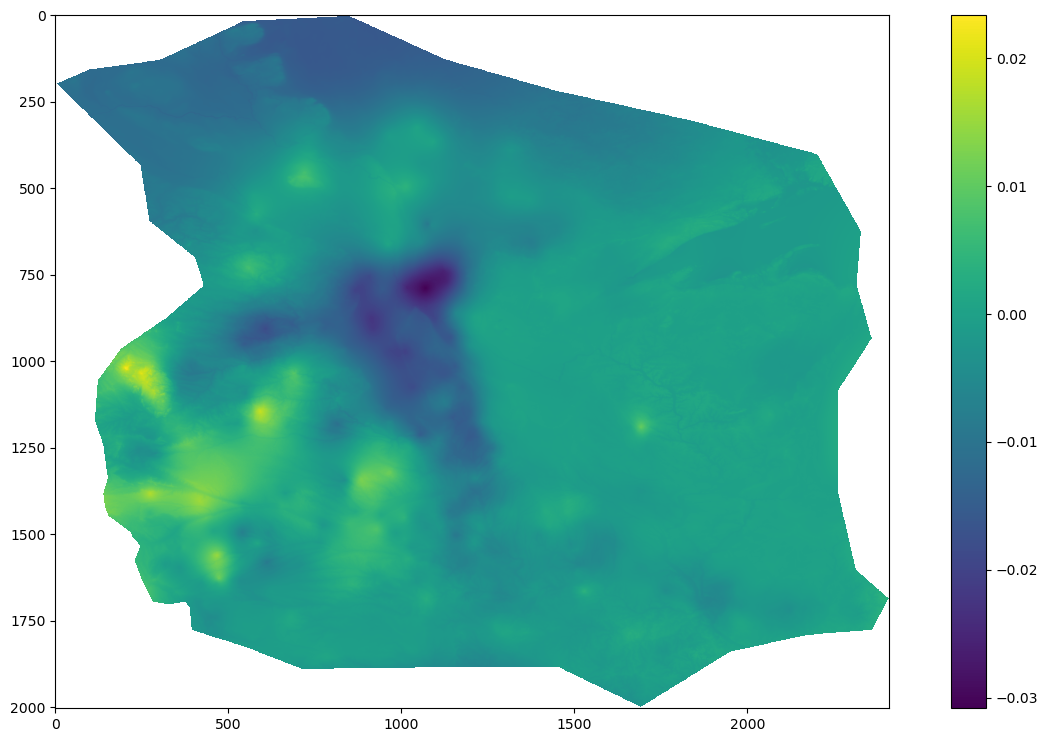

In [10]:
# Path to the TIFF file
tiff_file_path = r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\regression_kriging_DEMonly_interpolated_full_assimilation_without_UMRB_12_28_23.tif'

# Load the TIFF file using rasterio
with rasterio.open(tiff_file_path) as src:
    # Read the first band
    band1 = src.read(1)

    # Plot the image
plt.figure(figsize=(16,9))
plt.imshow(band1)
plt.colorbar()
plt.show()

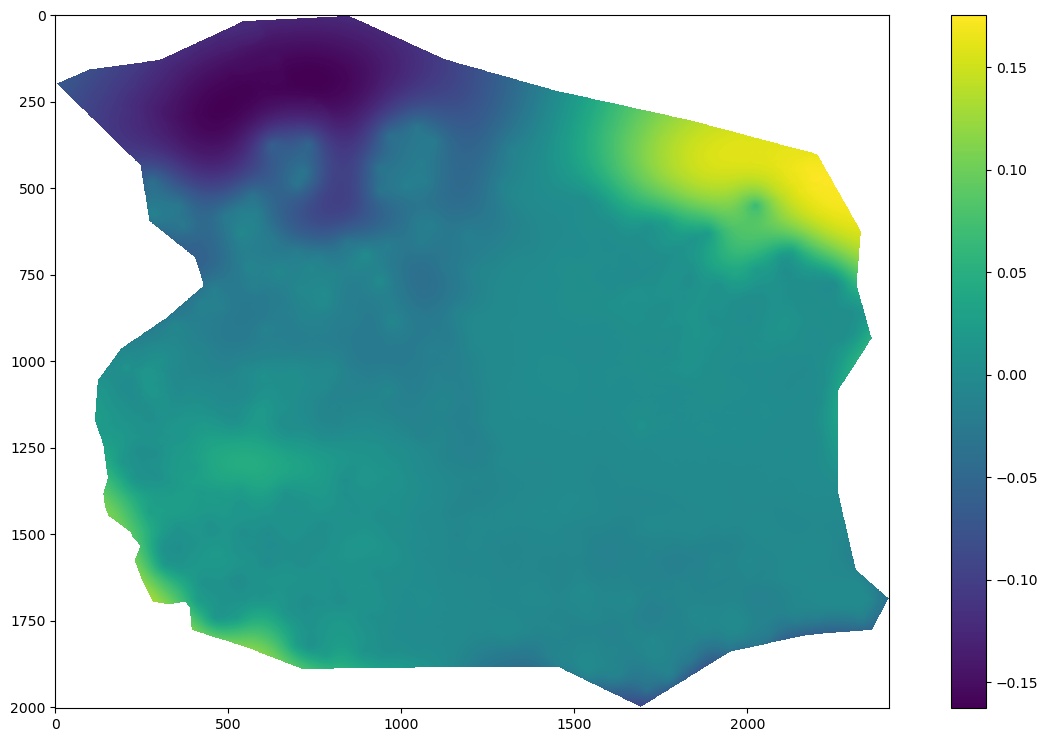

In [11]:
# Path to the TIFF file
tiff_file_path = r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\regression_kriging_DEMonly_interpolated_full_assimilation_with_UMRB_12_28_23.tif'

# Load the TIFF file using rasterio
with rasterio.open(tiff_file_path) as src:
    # Read the first band
    band1 = src.read(1)

    # Plot the image
plt.figure(figsize=(16,9))
plt.imshow(band1)
plt.colorbar()
plt.show()

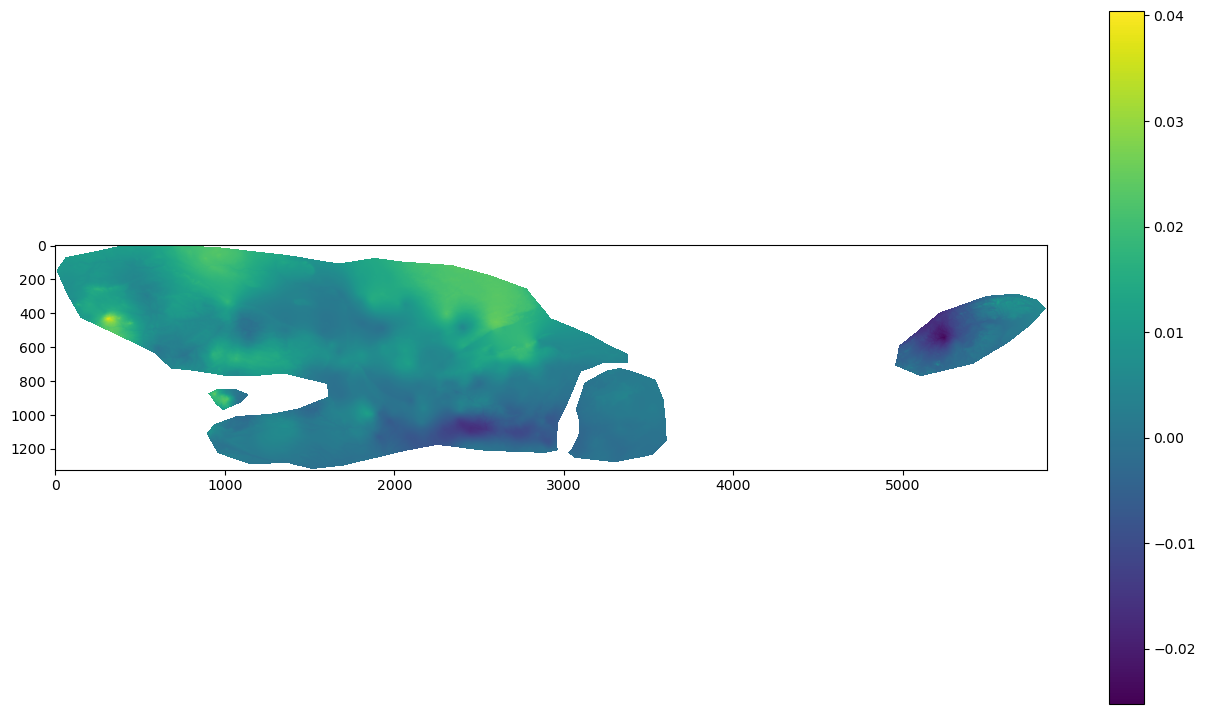

In [12]:
# Path to the TIFF file
tiff_file_path = r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\regression_kriging_DEMonly_interpolated_full_assimilation_with_UMRB_12_11_22.tif'

# Load the TIFF file using rasterio
with rasterio.open(tiff_file_path) as src:
    # Read the first band
    band1 = src.read(1)

    # Plot the image
plt.figure(figsize=(16,9))
plt.imshow(band1)
plt.colorbar()
plt.show()

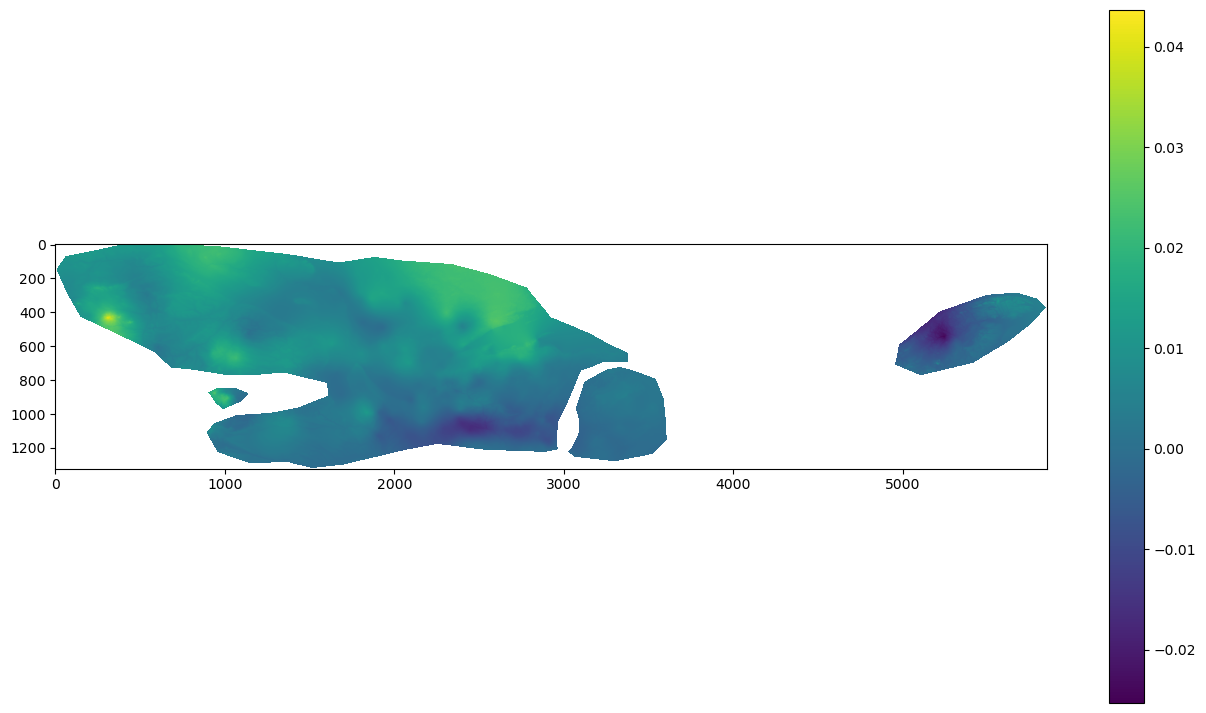

In [14]:
# Path to the TIFF file
tiff_file_path = r'C:\Users\clemasters\Research Triangle Institute\CIROH Basecamp - Documents\Projects\0218723.014 - SNODAS\Data\regression_kriging\regression_kriging_DEMonly_interpolated_full_assimilation_without_UMRB_12_11_22.tif'

# Load the TIFF file using rasterio
with rasterio.open(tiff_file_path) as src:
    # Read the first band
    band1 = src.read(1)

    # Plot the image
plt.figure(figsize=(16,9))
plt.imshow(band1)
plt.colorbar()
plt.show()

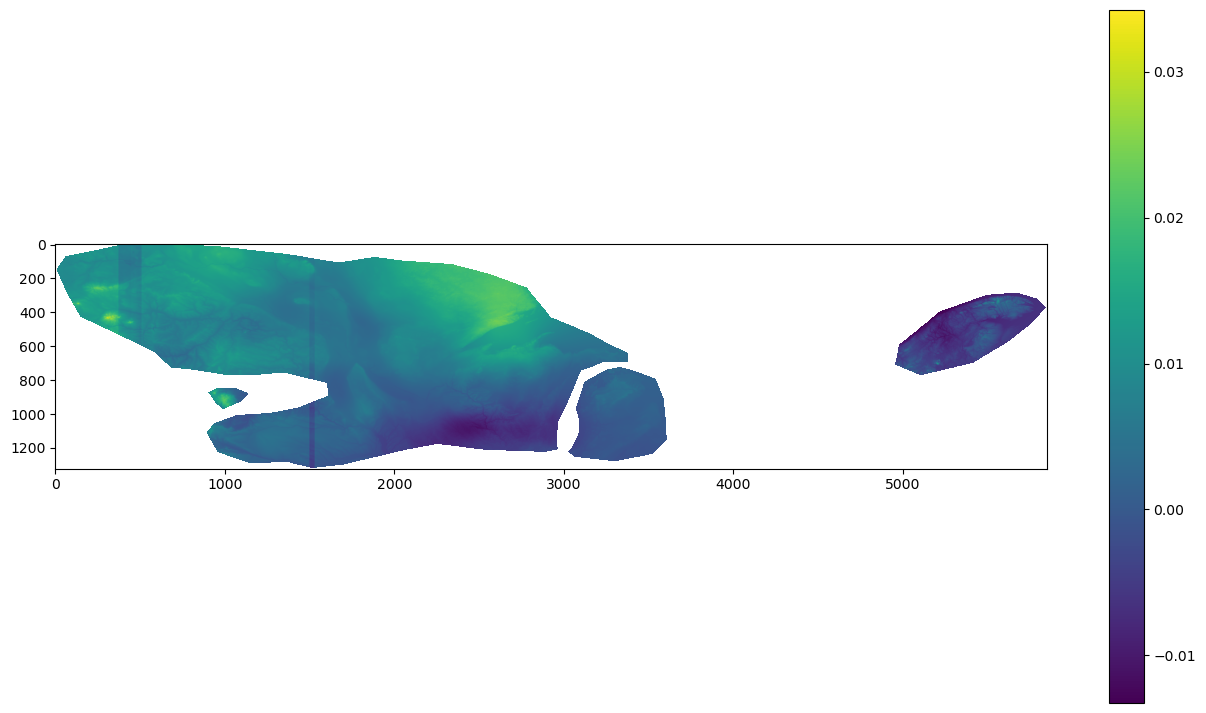

In [18]:
# Path to the TIFF file
tiff_file_path = r'C:\Repos\umrb-snodas\src\universal_kriging_full_assimilation_with_UMRB_12_11_22.tif'

# Load the TIFF file using rasterio
with rasterio.open(tiff_file_path) as src:
    # Read the first band
    band1 = src.read(1)

    # Plot the image
plt.figure(figsize=(16,9))
plt.imshow(band1)
plt.colorbar()
plt.show()

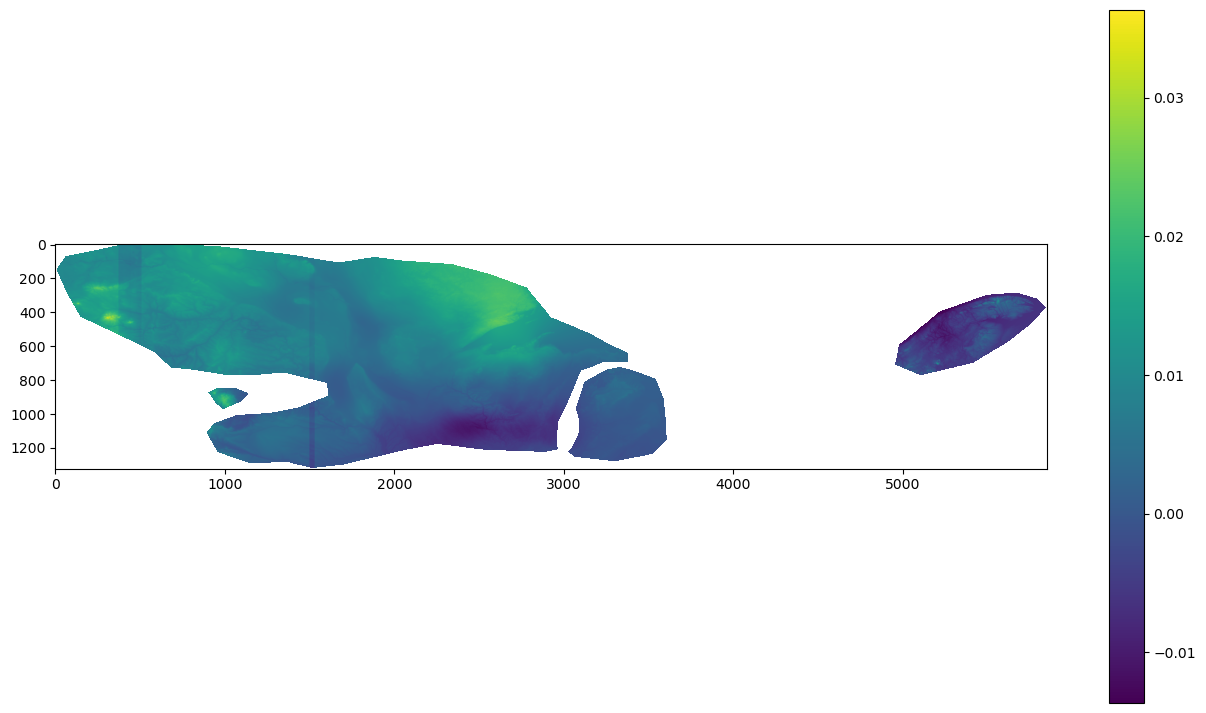

In [19]:
# Path to the TIFF file
tiff_file_path = r'C:\Repos\umrb-snodas\src\universal_kriging_full_assimilation_without_UMRB_12_11_22.tif'

# Load the TIFF file using rasterio
with rasterio.open(tiff_file_path) as src:
    # Read the first band
    band1 = src.read(1)

    # Plot the image
plt.figure(figsize=(16,9))
plt.imshow(band1)
plt.colorbar()
plt.show()

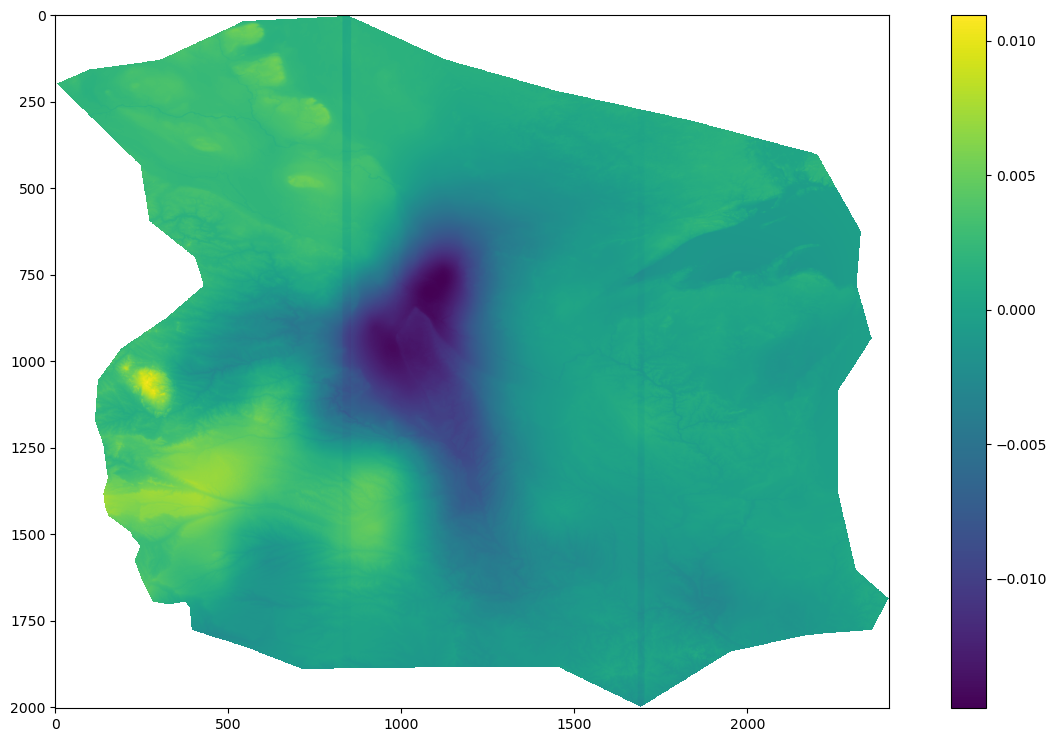

In [21]:
# Path to the TIFF file
tiff_file_path = r'C:\Repos\umrb-snodas\src\universal_kriging_full_assimilation_with_UMRB_12_28_23.tif'

# Load the TIFF file using rasterio
with rasterio.open(tiff_file_path) as src:
    # Read the first band
    band1 = src.read(1)

    # Plot the image
plt.figure(figsize=(16,9))
plt.imshow(band1)
plt.colorbar()
plt.show()

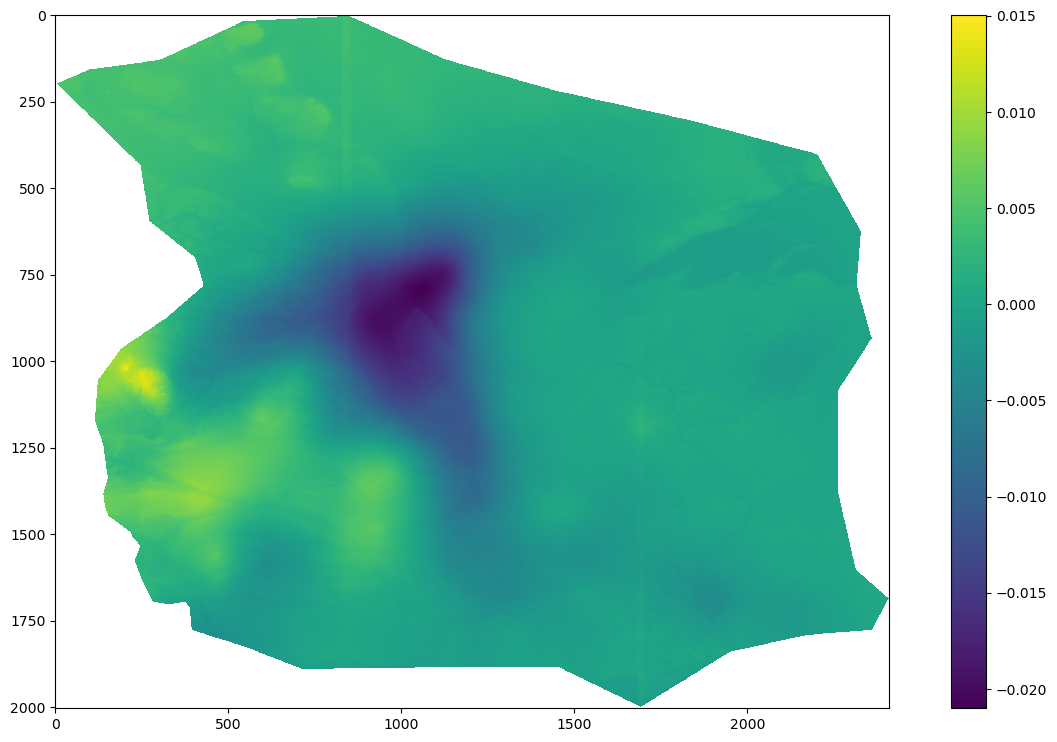

In [22]:
# Path to the TIFF file
tiff_file_path = r'C:\Repos\umrb-snodas\src\universal_kriging_full_assimilation_without_UMRB_12_28_23.tif'

# Load the TIFF file using rasterio
with rasterio.open(tiff_file_path) as src:
    # Read the first band
    band1 = src.read(1)

    # Plot the image
plt.figure(figsize=(16,9))
plt.imshow(band1)
plt.colorbar()
plt.show()